# vlm classifer 

* Qwen3.5-27B

In [61]:
import numpy as np
import pandas as pd
import nibabel as nib
import SimpleITK as sitk
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from pathlib import Path
from scipy import ndimage
import SimpleITK as sitk


import torch
import re
from PIL import Image
from enum import Enum
from pydantic import BaseModel
from transformers import Qwen3_5ForConditionalGeneration, AutoProcessor, BitsAndBytesConfig
from qwen_vl_utils import process_vision_info

NNUNET_ROOT = Path("/home/jovyan/aicon-gamma-datavol-1/hjgoh/ich-vlm/nnUNet")

In [62]:
class_map = {
    0: 'background',
    1: 'epidural',
    2: 'intraparenchymal',
    3: 'intraventricular',
    4: 'subarachnoid',
    5: 'subdural',
}

class_names = {
    1: 'EDH',
    2: 'IPH',
    3: 'IVH',
    4: 'SAH',
    5: 'SDH',
}

class_colors = {
    1: (198, 68, 66),    # EDH
    2: (76, 71, 199),    # IPH
    3: (171, 43, 171),   # IVH
    4: (168, 181, 112),  # SAH
    5: (4, 136, 133),    # SDH
}

class_names_1cls = {
    0: 'background',
    1: 'ich',
}

class_colors_1cls = {
    0: (0, 0, 0),
    1: (0, 255, 255),
}

In [63]:
# class mapping
def build_cmap(color_dict, n_classes):
    colors_rgb = np.zeros((n_classes, 3))
    for cls, rgb in color_dict.items():
        colors_rgb[cls] = np.array(rgb) / 255.0
    return ListedColormap(colors_rgb)

cmap_5cls = build_cmap(class_colors, 6)   # 0(background, black)~5
cmap_1cls = build_cmap(class_colors_1cls, 2)

# windowing
def apply_window(slice_hu, window_level=40, window_width=80):
    lo, hi = window_level - window_width / 2, window_level + window_width / 2
    return (np.clip(slice_hu, lo, hi) - lo) / (hi - lo)

In [64]:
DATASET = "002"             # "001"(5cls) or "002"(2cls)
TEST_SET = "MBH-Seg25"      # "MBH-Seg25"
CONFIG = "2d"               # "3d_fullres" or "2d"

IS_5CLS = (DATASET == "001")
N_CLASSES = 6 if IS_5CLS else 2
CMAP = cmap_5cls if IS_5CLS else cmap_1cls
CLS_NAMES = class_names if IS_5CLS else class_names_1cls
FG_CLASSES = list(class_names.keys()) if IS_5CLS else [1]

pred_root = NNUNET_ROOT / "nnUNet_predictions" / f"Dataset{DATASET}_MBHSeg25{'_1cls' if not IS_5CLS else ''}" / CONFIG / TEST_SET

if IS_5CLS:
    test_dir_name = "Test1_MBHSeg25" if TEST_SET == "MBH-Seg25" else "Test2_CTICH"
    gt_dir = NNUNET_ROOT / "test_data" / test_dir_name
else:
    test_dir_name = "Test1_MBHSeg25_1cls" if TEST_SET == "MBH-Seg25" else "Test2_CTICH_1cls"
    gt_dir = NNUNET_ROOT / "test_data_1cls" / test_dir_name

images_dir = gt_dir / "imagesTs"
labels_dir = gt_dir / "labelsTs"

print(f"설정: Dataset{DATASET} / {TEST_SET} / {CONFIG}")
print(f"GT: {gt_dir}")
print(f"예측: {pred_root}")

설정: Dataset002 / MBH-Seg25 / 2d
GT: /home/jovyan/aicon-gamma-datavol-1/hjgoh/ich-vlm/nnUNet/test_data_1cls/Test1_MBHSeg25_1cls
예측: /home/jovyan/aicon-gamma-datavol-1/hjgoh/ich-vlm/nnUNet/nnUNet_predictions/Dataset002_MBHSeg25_1cls/2d/MBH-Seg25


### Qwen

이전 버전: `Qwen3_5ForConditionalGeneration`을 4bit 양자화로 직접 로드
<br>현재 버전: vLLM 서버 + OpenAI client로 대체 

In [65]:
from openai import OpenAI
import base64
from io import BytesIO

client = OpenAI(base_url="http://localhost:8891/v1", api_key="EMPTY")
MODEL_NAME = "Qwen/Qwen3.5-27B"

def pil_to_base64_url(img: Image.Image) -> str:
    buf = BytesIO()
    img.save(buf, format="PNG")
    b64 = base64.b64encode(buf.getvalue()).decode("utf-8")
    return f"data:image/png;base64,{b64}"

GEN_CONFIGS = {
    "non_thinking": dict(
        temperature=0.0, max_tokens=1024, seed=0,
        extra_body={"chat_template_kwargs": {"enable_thinking": False}},
    ),
    
    #"thinking": dict(
        # max_tokens=1024/1536이면 사고가 안 끝나서 최종 답변(content)이 항상 비었음(직접 확인).
        # 4096으로 올리니 실제 사용량 completion_tokens~2000 안팎으로 자연 종료(finish_reason="stop").
    #    temperature=0.6, top_p=0.95, max_tokens=81920, seed=0,
    #    extra_body={"top_k": 20, "min_p": 0.0, "chat_template_kwargs": {"enable_thinking": True}},
    #),
}

### Image/Mask Function

In [66]:
def to_rgb_pil(img):
    """np.ndarray / PIL / 경로 어떤 형태로 들어와도 RGB PIL로 통일"""
    if isinstance(img, Image.Image):
        return img.convert("RGB")
    if isinstance(img, np.ndarray):
        if img.ndim == 2:
            img = np.stack([img] * 3, axis=-1)
        if img.shape[-1] == 4:
            img = img[..., :3]
        if img.dtype != np.uint8:
            img = img.astype(np.uint8)
        return Image.fromarray(img).convert("RGB")
    if isinstance(img, (str, bytes)):
        return Image.open(img).convert("RGB")
    raise TypeError(f"Unsupported image type: {type(img)}")


def extract_first_json(text: str) -> str:
    """모델 출력에서 첫 번째 완결된 JSON 객체만 잘라냄 (중첩 괄호 대응)"""
    start = text.find("{")
    if start == -1:
        raise ValueError(f"No JSON found: {text}")
    depth, end = 0, None
    for i, ch in enumerate(text[start:], start=start):
        if ch == "{":
            depth += 1
        elif ch == "}":
            depth -= 1
            if depth == 0:
                end = i + 1
                break
    if end is None:
        raise ValueError(f"Unterminated JSON: {text}")
    return text[start:end]


def load_lps_array(path):
    """DICOM 표준 axial view로 보이도록 LPS 재정렬 후 (z, y, x) 배열 반환."""
    img_sitk = sitk.ReadImage(str(path))
    img_lps = sitk.DICOMOrient(img_sitk, "LPS")
    return sitk.GetArrayFromImage(img_lps)


def overlay_mask(gray_float, mask, color=(0, 255, 255), alpha=0.4):
    """gray_float: 0~1 float 2D. mask: 0/1 2D. -> uint8 RGB array"""
    rgb = np.stack([gray_float] * 3, axis=-1)
    color_arr = np.array(color, dtype=np.float32) / 255.0
    m = mask.astype(bool)
    rgb[m] = (1 - alpha) * rgb[m] + alpha * color_arr
    return (np.clip(rgb, 0, 1) * 255).astype(np.uint8)

In [67]:
def get_lesion_instances(mask_slice, windowed_slice, min_pixels=5, pad=15):
    """
    2D 슬라이스 하나(mask_slice, windowed_slice)만 보고, 
    그 슬라이스 안에서 서로 붙어있지 않은 영역들을 연결요소(2D)로 분리해서 인스턴스별
    (전체 하이라이트 이미지, 크롭 이미지) 쌍을 만듦. 
    다른 z 슬라이스는 전혀 보지 않음.
    """
    labeled, n = ndimage.label(mask_slice > 0)  # 2D 라벨링 (기본 4-connectivity)
    instances = []
    
    for i in range(1, n + 1):
        inst_mask = labeled == i
        pixel_count = int(inst_mask.sum())
        if pixel_count < min_pixels:
            continue

        full_arr = overlay_mask(windowed_slice, inst_mask)
        full_img = to_rgb_pil(full_arr)

        ys, xs = np.where(inst_mask)
        y0, y1 = max(ys.min() - pad, 0), min(ys.max() + pad, windowed_slice.shape[0])
        x0, x1 = max(xs.min() - pad, 0), min(xs.max() + pad, windowed_slice.shape[1])
        crop_arr = (windowed_slice[y0:y1, x0:x1] * 255).astype(np.uint8)
        crop_img = to_rgb_pil(crop_arr)

        instances.append({
            "instance_id": i,
            "pixel_count": pixel_count,
            "full_img": full_img,
            "crop_img": crop_img,
            "mask": inst_mask
        })
    return instances

### Output Schema

In [68]:
# llm-classify_v2의 structured output 패턴
# ICH 5-class + NONE(진짜 병변이 아니라고 판단될 때, 과검출 필터링용)
# free-text reasoning 필드를 guided JSON 스키마 안에 강제하는 게 이 vLLM 백엔드에서
# 불안정해서(maxLength로도 못 막힘, "Unterminated JSON" 대량 실패) 완전히 뺐다.
# 진짜 reasoning은 --reasoning-parser + enable_thinking의 message.reasoning_content로 받는다.

class ICHType(str, Enum):
    edh = "EDH"
    sdh = "SDH"
    sah = "SAH"
    ivh = "IVH"
    iph = "IPH"
    none = "NONE"

class ICHResult(BaseModel):
    is_lesion: bool
    lesion_type: ICHType

### Prompt Builder

In [ ]:
def build_prompt():
    return """
    You are Reader #2, providing an independent second read of a candidate brain hemorrhage finding
    from a non-contrast head CT, originally flagged by a segmentation model (Reader #1). You do not
    see Reader #1's classification — judge independently from the images alone.

    You are given two images of the flagged region.
    Image 1: the full axial slice, with the flagged region highlighted, showing its location relative
    to the skull/ventricles/brain surface.
    Image 2: a zoomed-in crop of the region, showing its shape and density pattern in detail.

    Reader #1 (the segmentation model) can make mistakes (false positives from artifacts, calcification,
    bone, noise, etc). Small or subtle true hemorrhages are common — do not default to NONE just because
    the finding is small or faint; judge based on location, shape, and density pattern, not size alone.

    Definitions:
    - EDH (epidural): biconvex/lens-shaped, sharply demarcated.
      Limited by cranial sutures (does NOT cross them) — but CAN cross midline/dural reflections (falx, venous sinuses).
      Usually hyperdense, homogeneous.

    - SDH (subdural): crescent-shaped, follows brain surface, CAN cross suture lines,
      but is limited by falx cerebri, tentorium, and falx cerebelli (won't cross midline via falx).
      Shape may become biconvex in chronic stage.
      Density highly variable (hyper/iso/hypodense possible) —
      do NOT rule out SDH based on density alone.
      If isodense/subtle: rely on mass effect / sulcal effacement instead.
    
    - SAH (subarachnoid): thin, follows sulci/cisterns/fissures — NOT a round/focal mass.
      Often bilateral/diffuse, fragmented; commonly in interhemispheric fissure,
      sylvian fissure, or basal cisterns (around circle of Willis).
      Distinguish from IVH: SAH outlines sulci/cisterns, IVH fills ventricles.
      Small-volume SAH can be subtle — check sulcal/cisternal effacement, not density alone.
    
    - IVH (intraventricular): confined within ventricle boundaries, tends to pool
      dependently (occipital horns). Do NOT confuse with choroid plexus calcification,
      which is a normal finding in the same region.
    
    - IPH (intraparenchymal): within brain tissue, not confined to a thin space.
      Common locations: basal ganglia/thalamus/pons/cerebellum (often hypertensive),
      or lobar (often amyloid angiopathy in older patients). May show surrounding
      hypodense edema and can extend into ventricles (IVH) or subarachnoid space (SAH).
    
    - NONE: not a real hemorrhage (artifact, calcification — e.g. choroid plexus,
      falx, pineal gland —, bone, noise).

    Multiplicity notes (a single slice can contain several separate instances of the same subtype):
    - SAH commonly appears in multiple, separate sulci at once.
    - IVH is often distributed across both lateral ventricles.
    - Traumatic IPH frequently presents as multiple scattered contusions rather than one lesion.
    - SDH and EDH are usually a single lesion, but can appear as separate instances when bilateral, or located at different dural attachment sites (falx, tentorium).

    Judge whether this is a true hemorrhage lesion (is_lesion), and if so classify the subtype into one of:
    EDH, SDH, SAH, IVH, IPH. If not a true lesion, set lesion_type to NONE.

    STRICT OUTPUT RULES: Do NOT write any analysis, explanation, or text outside the JSON. Output ONLY the JSON object below, with nothing before or after it.
    {"is_lesion": true/false, "lesion_type": "EDH/SDH/SAH/IVH/IPH/NONE"}
    """


def build_stage1_prompt():
    """2단계 호출의 1단계(자유 사고) 전용 프롬프트 — response_format 없이 이걸로 호출한다.
    "정확히 두 문장" 같은 길이 제약 없이 자유롭게 서술하게 둔다(요약을 강요하면 모델이 그 형식을
    맞추려다 오히려 결론을 못 내는 경우가 있어서 롤백함) — 짧게 끝나든 길게 낙서하듯 끝나든
    있는 그대로 native_reasoning/prior_analysis로 사용한다. max_tokens는 GEN_CONFIGS["thinking"]에서
    4096으로 넉넉히 줘야 한다(1024/1536이면 사고 도중 잘려서 content가 계속 비었음, 직접 확인)."""

    return """
    You are given two images of a region that a segmentation model marked as a possible brain hemorrhage, from a non-contrast head CT.
    Image 1: the full axial slice, with the segmented region highlighted, showing its location relative to the skull/ventricles/brain surface.
    Image 2: a zoomed-in crop of the region, showing its shape and density pattern in detail.

    The segmentation model can make mistakes (false positives from artifacts, calcification, bone, noise, etc).
    Small or subtle true hemorrhages are common — do not default to NONE just because the finding is small or faint.

    Definitions:
    - EDH (epidural): lens-shaped (biconvex), does not cross suture lines
    - SDH (subdural): crescent-shaped, follows brain surface, can cross suture lines
    - SAH (subarachnoid): thin, follows sulci/cisterns, often fragmented
    - IVH (intraventricular): confined within ventricle boundaries
    - IPH (intraparenchymal): within brain tissue, not confined to a thin space
    - NONE: not a real hemorrhage (artifact/false positive)

    Multiplicity notes (a single slice can contain several separate instances of the same subtype):
    - SAH commonly appears in multiple, separate sulci at once.
    - IVH is often distributed across both lateral ventricles.
    - Traumatic IPH frequently presents as multiple scattered contusions rather than one lesion.
    - SDH and EDH are usually a single lesion, but can appear as separate instances when bilateral, or located at different dural attachment sites (falx, tentorium).

    Analyze this candidate region: describe its location, shape, and density pattern in a few sentences, then
    state your conclusion on whether it is a true hemorrhage (and which subtype) or a false positive. This
    analysis will be used as context for a separate final judgment, so be concrete and concise — no need to
    output JSON here.
    """

### Message Builder

In [70]:
# tomato_vlm_v1의 few-shot 패턴.
# 클래스별 대표 crop을 몇 장 준비
# OpenAI 호환 API는 PIL 객체를 직접 못 받아서 image_url(base64)로 인코딩해서 넣는다.
def build_reference_messages(ref_examples: dict):
    """ref_examples = {"EDH": [PIL_img, ...], "SDH": [...], ...}"""
    
    msgs = [{
        "role": "system",
        "content": [{"type": "text", "text": "You will see reference examples of each hemorrhage subtype before the target image."}]
    }]
    for label, images in ref_examples.items():
        for img in images:
            msgs.append({
                "role": "user",
                "content": [
                    {"type": "text", "text": f"Reference: {label}"},
                    {"type": "image_url", "image_url": {"url": pil_to_base64_url(to_rgb_pil(img))}}
                ]
            })
    return msgs

In [71]:
from pydantic import ValidationError

def _response_format():
    return {
        "type": "json_schema",
        "json_schema": {"name": ICHResult.__name__, "schema": ICHResult.model_json_schema()},
    }

def _build_messages(full_img, crop_img, ref_examples=None, use_examples=False):
    messages = []
    if use_examples and ref_examples:
        messages.extend(build_reference_messages(ref_examples))
    content = [
        {"type": "text", "text": "Classify this hemorrhage lesion."},
        {"type": "text", "text": "Image 1 (full slice):"},
        {"type": "image_url", "image_url": {"url": pil_to_base64_url(full_img)}},
        {"type": "text", "text": "Image 2 (zoomed crop):"},
        {"type": "image_url", "image_url": {"url": pil_to_base64_url(crop_img)}},
        {"type": "text", "text": build_prompt()},
    ]
    messages.append({"role": "user", "content": content})
    return messages


def _parse_result(text):
    js = extract_first_json(text)
    r = ICHResult.model_validate_json(js)
    return (r.is_lesion, r.lesion_type.value)


def classify_lesion_one(full_img, crop_img, ref_examples=None, use_examples=False, max_retries=1):
    """non_thinking 고정. 반환: (is_lesion, lesion_type). 파싱 실패 시 재시도 후 안 되면 NONE 처리."""
    full_img, crop_img = to_rgb_pil(full_img), to_rgb_pil(crop_img)
    messages = _build_messages(full_img, crop_img, ref_examples, use_examples)

    last_err = None
    for _ in range(max_retries + 1):
        r = client.chat.completions.create(
            model=MODEL_NAME, messages=messages,
            response_format=_response_format(), **GEN_CONFIGS["non_thinking"],
        )
        try:
            return _parse_result(r.choices[0].message.content)
        except (ValueError, ValidationError) as e:
            last_err = e

    print(f"[경고] 파싱 실패, NONE으로 처리: {last_err}")
    return (False, "NONE")


def classify_lesion_batch(image_pairs, ref_examples=None, use_examples=False, max_workers=8):
    """반환: [(is_lesion, lesion_type), ...]"""
    from concurrent.futures import ThreadPoolExecutor

    def _one(pair):
        full_img, crop_img = pair
        return classify_lesion_one(full_img, crop_img, ref_examples, use_examples)

    with ThreadPoolExecutor(max_workers=max_workers) as ex:
        return list(ex.map(_one, image_pairs))


### 실험: 260818_vlm_mbhseg_dataset 기반 VLM 분류 — non_thinking

* 260818_vlm_mbhseg_dataset/dataset.json: 2cls(binary) 예측 후보 인스턴스마다 인스턴스별
  overlay/crop 이미지 + 정답(is_lesion/gt_class_name)이 들어있는, 5cls와 동일한 구조의 데이터셋.
* non_thinking으로만 분류한다 (thinking 비교 없음, pred 서브타입도 없어서 GT 비교만 함).


In [72]:
import json
import re

VLM_DATASET_JSON = Path("/home/jovyan/aicon-gamma-datavol-1/hjgoh/ich-vlm/experiments/260818_vlm_mbhseg_dataset/dataset.json")
with open(VLM_DATASET_JSON, encoding="utf-8") as f:
    gt_records = json.load(f)

gt_by_id = {r["id"]: r for r in gt_records}

EXP_OUT_DIR = Path("/home/jovyan/aicon-gamma-datavol-1/hjgoh/ich-vlm/experiments/260818_vlm-classify-mbhseg-dataset")
(EXP_OUT_DIR / "output").mkdir(parents=True, exist_ok=True)

dataset_case_ids = sorted({r["case_id"] for r in gt_records})
pilot_case_ids = dataset_case_ids[:5]
print(f"dataset.json 인스턴스 수: {len(gt_records)}  /  케이스 수: {len(dataset_case_ids)}")
print("파일럿 5개:", pilot_case_ids)


def instance_number(record):
    m = re.search(r"_inst(\d+)$", record["id"])
    return int(m.group(1)) if m else 0


def group_by_slice(records):
    groups = {}
    for r in records:
        groups.setdefault((r["case_id"], r["slice_idx"]), []).append(r)
    for key in groups:
        groups[key].sort(key=instance_number)
    return sorted(groups.items(), key=lambda kv: kv[0])


def classify_dataset_records(records, max_workers=8):
    """(case_id, slice_idx) 슬라이스 그룹 단위로 순차 진행, 슬라이스 안 인스턴스는 병렬 처리.
    non_thinking 고정."""
    merged = []
    for (case_id, slice_idx), slice_records in group_by_slice(records):
        image_pairs = [
            (Image.open(r["images"]["overlay"]), Image.open(r["images"]["cropped"]))
            for r in slice_records
        ]
        results = classify_lesion_batch(image_pairs, use_examples=False, max_workers=max_workers)
        for r, (is_lesion, lesion_type) in zip(slice_records, results):
            merged.append({
                "id": r["id"], "case_id": r["case_id"], "slice_idx": r["slice_idx"],
                "instance_number": instance_number(r),
                "bbox": r["bbox"], "area_px": r["area_px"], "images": r["images"],
                "vlm_is_lesion": is_lesion, "vlm_lesion_type": lesion_type,
            })
    return merged


def with_ground_truth(pred_records):
    """gt_is_lesion/gt_class_name 이름은 5cls 노트북과 통일."""
    rows = []
    for r in pred_records:
        gt = gt_by_id[r["id"]]
        rows.append({**r, "gt_is_lesion": gt["is_lesion"], "gt_class_name": gt["gt_class_name"]})
    return rows


def run_classification(case_ids, tag):
    case_id_set = set(case_ids)
    records = [r for r in gt_records if r["case_id"] in case_id_set]
    print(f"=== non_thinking ({len(records)}개 인스턴스) ===")
    merged = classify_dataset_records(records)
    out_json = EXP_OUT_DIR / "output" / f"{tag}_predictions_non_thinking.json"
    with open(out_json, "w", encoding="utf-8") as f:
        json.dump(merged, f, ensure_ascii=False, indent=2)
    print(f"  저장: {out_json}")
    return merged

dataset.json 인스턴스 수: 958  /  케이스 수: 43
파일럿 5개: ['ID_0219ef88_ID_e5c1a31210', 'ID_066b1fc2_ID_f937d7bff0', 'ID_095c522a_ID_19cfefdccb', 'ID_0a040036_ID_44cc017f8a', 'ID_0bee00a2_ID_0b9e78b135']


In [73]:
# 저장된 결과(full_predictions_non_thinking.json)를 그대로 쓰기로 해서 재실행 안 함 (아래 04e9b2cc 셀에서 로드)
# pilot_results = run_classification(pilot_case_ids, tag="pilot")

In [74]:
# 저장된 결과(full_predictions_non_thinking.json)를 그대로 쓰기로 해서 재실행 안 함 (아래 04e9b2cc 셀에서 로드)
# full_results = run_classification(dataset_case_ids, tag="full")

In [75]:
def compare_judgment(df, subj_is_lesion_col, subj_class_col, ref_is_lesion_col, ref_class_col, subj_label, ref_label):
    detect_acc = (df[subj_is_lesion_col] == df[ref_is_lesion_col]).mean()
    print(f"[{subj_label} vs {ref_label}] 병변 유무 판정 일치율: {detect_acc:.4f}  (n={len(df)})")

    agree = df[df[ref_is_lesion_col] & df[subj_is_lesion_col]]
    if not agree.empty:
        cls_acc = (agree[subj_class_col] == agree[ref_class_col]).mean()
        print(f"[{subj_label} vs {ref_label}] 클래스 일치율(둘 다 병변으로 본 것 중): {cls_acc:.4f}  (n={len(agree)})")
        confusion = pd.crosstab(agree[ref_class_col], agree[subj_class_col], rownames=[ref_label], colnames=[subj_label])
        display(confusion)
        per_class = agree.groupby(ref_class_col).apply(lambda g: (g[subj_class_col] == g.name).mean())
        print(f"[{subj_label} vs {ref_label}] 클래스별 정확도:")
        print(per_class.round(4))

    return detect_acc

def summarize_vlm(pred_records):
    df = pd.DataFrame(with_ground_truth(pred_records))

    print("=== VLM vs GT ===")
    compare_judgment(df, "vlm_is_lesion", "vlm_lesion_type", "gt_is_lesion", "gt_class_name", "VLM", "GT")

    return df

# 새로 VLM을 호출하지 않고, 이미 저장된 결과 파일을 그대로 불러와서 씀
FULL_RESULTS_JSON = EXP_OUT_DIR / "output" / "full_predictions_non_thinking.json"
with open(FULL_RESULTS_JSON, encoding="utf-8") as f:
    full_results = json.load(f)

results_to_eval = full_results
vlm_eval_df = summarize_vlm(results_to_eval)

=== VLM vs GT ===
[VLM vs GT] 병변 유무 판정 일치율: 0.5762  (n=958)
[VLM vs GT] 클래스 일치율(둘 다 병변으로 본 것 중): 0.5634  (n=410)


VLM,EDH,IPH,IVH,SAH,SDH
GT,,,,,
EDH,0,0,0,0,4
IPH,2,68,1,5,8
IVH,0,46,13,2,0
SAH,0,66,0,83,12
SDH,12,5,1,15,67


[VLM vs GT] 클래스별 정확도:
gt_class_name
EDH    0.0000
IPH    0.8095
IVH    0.2131
SAH    0.5155
SDH    0.6700
dtype: float64


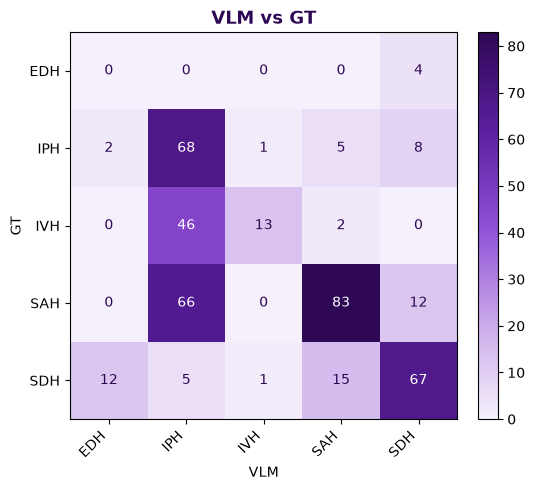

In [76]:
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

PURPLE_CMAP = LinearSegmentedColormap.from_list(
    "purple_theme", ["#f5f0fb", "#c9a8e9", "#8e4fd6", "#5b1f9e", "#2e0854"]
)

def plot_confusion(confusion_df, title="Confusion Matrix"):
    fig, ax = plt.subplots(figsize=(6, 5))
    im = ax.imshow(confusion_df.values, cmap=PURPLE_CMAP)

    ax.set_xticks(range(len(confusion_df.columns)))
    ax.set_xticklabels(confusion_df.columns, rotation=45, ha="right")
    ax.set_yticks(range(len(confusion_df.index)))
    ax.set_yticklabels(confusion_df.index)
    ax.set_xlabel(confusion_df.columns.name or "")
    ax.set_ylabel(confusion_df.index.name or "")
    ax.set_title(title, fontsize=13, fontweight="bold", color="#2e0854")

    vmax = confusion_df.values.max()
    for i in range(confusion_df.shape[0]):
        for j in range(confusion_df.shape[1]):
            val = confusion_df.values[i, j]
            color = "white" if val > vmax * 0.55 else "#2e0854"
            ax.text(j, i, val, ha="center", va="center", color=color, fontsize=10)

    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    fig.tight_layout()
    plt.show()


# VLM vs GT
tp = vlm_eval_df[vlm_eval_df["gt_is_lesion"] & vlm_eval_df["vlm_is_lesion"]]
confusion = pd.crosstab(tp["gt_class_name"], tp["vlm_lesion_type"], rownames=["GT"], colnames=["VLM"])
plot_confusion(confusion, "VLM vs GT")


오답 585개 / 전체 958개 (정확도 0.3894)

[case_idx=0] ID_0219ef88_ID_e5c1a31210_s013_inst1  GT=SDH  VLM=NONE



[case_idx=1] ID_066b1fc2_ID_f937d7bff0_s011_inst1  GT=IVH  VLM=IPH



[case_idx=1] ID_066b1fc2_ID_f937d7bff0_s012_inst1  GT=IVH  VLM=NONE



[case_idx=1] ID_066b1fc2_ID_f937d7bff0_s013_inst1  GT=IVH  VLM=IPH



[case_idx=1] ID_066b1fc2_ID_f937d7bff0_s013_inst2  GT=IVH  VLM=NONE



[case_idx=2] ID_095c522a_ID_19cfefdccb_s017_inst1  GT=SDH  VLM=NONE


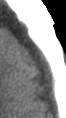


[case_idx=2] ID_095c522a_ID_19cfefdccb_s018_inst1  GT=SDH  VLM=NONE


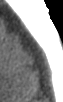


[case_idx=3] ID_0a040036_ID_44cc017f8a_s013_inst2  GT=NONE  VLM=IPH



[case_idx=3] ID_0a040036_ID_44cc017f8a_s014_inst1  GT=IPH  VLM=SDH


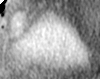


[case_idx=3] ID_0a040036_ID_44cc017f8a_s014_inst2  GT=SDH  VLM=IPH


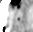


[case_idx=3] ID_0a040036_ID_44cc017f8a_s014_inst3  GT=NONE  VLM=IPH



[case_idx=3] ID_0a040036_ID_44cc017f8a_s015_inst2  GT=SDH  VLM=NONE


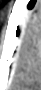


[case_idx=3] ID_0a040036_ID_44cc017f8a_s016_inst2  GT=SDH  VLM=NONE


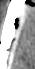


[case_idx=3] ID_0a040036_ID_44cc017f8a_s018_inst1  GT=NONE  VLM=IPH



[case_idx=4] ID_0bee00a2_ID_0b9e78b135_s007_inst1  GT=IPH  VLM=NONE



[case_idx=4] ID_0bee00a2_ID_0b9e78b135_s012_inst2  GT=IVH  VLM=IPH



[case_idx=4] ID_0bee00a2_ID_0b9e78b135_s013_inst1  GT=IVH  VLM=IPH


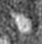


[case_idx=4] ID_0bee00a2_ID_0b9e78b135_s013_inst3  GT=IVH  VLM=IPH



[case_idx=4] ID_0bee00a2_ID_0b9e78b135_s014_inst1  GT=IVH  VLM=IPH


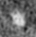


[case_idx=4] ID_0bee00a2_ID_0b9e78b135_s014_inst2  GT=NONE  VLM=IPH


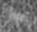


[case_idx=4] ID_0bee00a2_ID_0b9e78b135_s015_inst1  GT=IVH  VLM=IPH



[case_idx=4] ID_0bee00a2_ID_0b9e78b135_s015_inst2  GT=IVH  VLM=NONE



[case_idx=4] ID_0bee00a2_ID_0b9e78b135_s016_inst1  GT=IVH  VLM=NONE



[case_idx=4] ID_0bee00a2_ID_0b9e78b135_s017_inst1  GT=IVH  VLM=SAH



[case_idx=4] ID_0bee00a2_ID_0b9e78b135_s018_inst1  GT=IVH  VLM=IPH


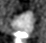


[case_idx=4] ID_0bee00a2_ID_0b9e78b135_s018_inst2  GT=IVH  VLM=IPH



[case_idx=4] ID_0bee00a2_ID_0b9e78b135_s019_inst2  GT=IVH  VLM=IPH



[case_idx=4] ID_0bee00a2_ID_0b9e78b135_s020_inst1  GT=IVH  VLM=IPH


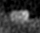


[case_idx=4] ID_0bee00a2_ID_0b9e78b135_s021_inst1  GT=IVH  VLM=NONE



[case_idx=4] ID_0bee00a2_ID_0b9e78b135_s024_inst1  GT=SDH  VLM=NONE


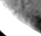


[case_idx=4] ID_0bee00a2_ID_0b9e78b135_s025_inst1  GT=SDH  VLM=NONE


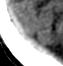


[case_idx=4] ID_0bee00a2_ID_0b9e78b135_s027_inst1  GT=SDH  VLM=NONE


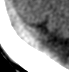


[case_idx=4] ID_0bee00a2_ID_0b9e78b135_s028_inst2  GT=SDH  VLM=NONE



[case_idx=4] ID_0bee00a2_ID_0b9e78b135_s029_inst1  GT=SDH  VLM=NONE


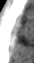


[case_idx=4] ID_0bee00a2_ID_0b9e78b135_s030_inst1  GT=SAH  VLM=NONE



[case_idx=4] ID_0bee00a2_ID_0b9e78b135_s031_inst1  GT=SAH  VLM=IPH


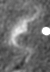


[case_idx=4] ID_0bee00a2_ID_0b9e78b135_s031_inst2  GT=SAH  VLM=IPH


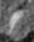


[case_idx=4] ID_0bee00a2_ID_0b9e78b135_s032_inst1  GT=SAH  VLM=IPH


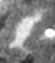


[case_idx=4] ID_0bee00a2_ID_0b9e78b135_s032_inst2  GT=SAH  VLM=IPH



[case_idx=4] ID_0bee00a2_ID_0b9e78b135_s032_inst3  GT=SAH  VLM=IPH



[case_idx=7] ID_0d0f361b_ID_17542973dc_s010_inst1  GT=NONE  VLM=IPH


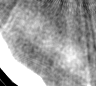


[case_idx=7] ID_0d0f361b_ID_17542973dc_s011_inst1  GT=SDH  VLM=IPH


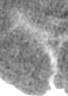


[case_idx=7] ID_0d0f361b_ID_17542973dc_s012_inst1  GT=IPH  VLM=NONE


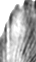


[case_idx=7] ID_0d0f361b_ID_17542973dc_s013_inst1  GT=IPH  VLM=SDH


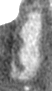


[case_idx=7] ID_0d0f361b_ID_17542973dc_s013_inst2  GT=SAH  VLM=SDH


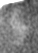


[case_idx=7] ID_0d0f361b_ID_17542973dc_s013_inst3  GT=SAH  VLM=NONE



[case_idx=7] ID_0d0f361b_ID_17542973dc_s013_inst4  GT=SDH  VLM=SAH



[case_idx=7] ID_0d0f361b_ID_17542973dc_s013_inst5  GT=IVH  VLM=NONE



[case_idx=7] ID_0d0f361b_ID_17542973dc_s013_inst6  GT=SDH  VLM=SAH



[case_idx=7] ID_0d0f361b_ID_17542973dc_s014_inst1  GT=IPH  VLM=SAH


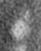


[case_idx=7] ID_0d0f361b_ID_17542973dc_s014_inst5  GT=SAH  VLM=IPH


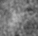


[case_idx=7] ID_0d0f361b_ID_17542973dc_s014_inst6  GT=SAH  VLM=NONE


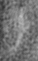


[case_idx=7] ID_0d0f361b_ID_17542973dc_s014_inst7  GT=IVH  VLM=IPH



[case_idx=7] ID_0d0f361b_ID_17542973dc_s014_inst8  GT=IVH  VLM=IPH


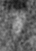


[case_idx=7] ID_0d0f361b_ID_17542973dc_s014_inst9  GT=IVH  VLM=IPH


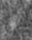


[case_idx=7] ID_0d0f361b_ID_17542973dc_s014_inst10  GT=SDH  VLM=SAH



[case_idx=7] ID_0d0f361b_ID_17542973dc_s015_inst1  GT=SDH  VLM=NONE



[case_idx=7] ID_0d0f361b_ID_17542973dc_s015_inst2  GT=SAH  VLM=NONE



[case_idx=7] ID_0d0f361b_ID_17542973dc_s015_inst3  GT=SAH  VLM=NONE


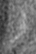


[case_idx=7] ID_0d0f361b_ID_17542973dc_s015_inst4  GT=IVH  VLM=NONE



[case_idx=7] ID_0d0f361b_ID_17542973dc_s015_inst5  GT=IVH  VLM=IPH


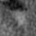


[case_idx=7] ID_0d0f361b_ID_17542973dc_s015_inst6  GT=SDH  VLM=SAH



[case_idx=7] ID_0d0f361b_ID_17542973dc_s015_inst7  GT=SDH  VLM=NONE



[case_idx=7] ID_0d0f361b_ID_17542973dc_s016_inst1  GT=SAH  VLM=NONE



[case_idx=7] ID_0d0f361b_ID_17542973dc_s016_inst2  GT=SAH  VLM=NONE



[case_idx=7] ID_0d0f361b_ID_17542973dc_s016_inst3  GT=SAH  VLM=IPH



[case_idx=7] ID_0d0f361b_ID_17542973dc_s016_inst4  GT=SAH  VLM=NONE



[case_idx=7] ID_0d0f361b_ID_17542973dc_s016_inst5  GT=IVH  VLM=NONE


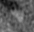


[case_idx=7] ID_0d0f361b_ID_17542973dc_s017_inst2  GT=NONE  VLM=SDH



[case_idx=7] ID_0d0f361b_ID_17542973dc_s017_inst4  GT=SAH  VLM=NONE



[case_idx=7] ID_0d0f361b_ID_17542973dc_s017_inst5  GT=NONE  VLM=SDH



[case_idx=7] ID_0d0f361b_ID_17542973dc_s017_inst6  GT=SDH  VLM=NONE



[case_idx=7] ID_0d0f361b_ID_17542973dc_s017_inst9  GT=IVH  VLM=NONE


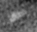


[case_idx=7] ID_0d0f361b_ID_17542973dc_s017_inst10  GT=IVH  VLM=IPH


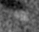


[case_idx=7] ID_0d0f361b_ID_17542973dc_s017_inst11  GT=SAH  VLM=NONE



[case_idx=7] ID_0d0f361b_ID_17542973dc_s018_inst1  GT=NONE  VLM=SAH


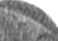


[case_idx=7] ID_0d0f361b_ID_17542973dc_s018_inst3  GT=NONE  VLM=SDH


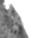


[case_idx=7] ID_0d0f361b_ID_17542973dc_s018_inst5  GT=IVH  VLM=IPH



[case_idx=7] ID_0d0f361b_ID_17542973dc_s018_inst6  GT=IVH  VLM=NONE



[case_idx=7] ID_0d0f361b_ID_17542973dc_s019_inst2  GT=NONE  VLM=SDH


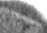


[case_idx=7] ID_0d0f361b_ID_17542973dc_s019_inst3  GT=SAH  VLM=NONE



[case_idx=7] ID_0d0f361b_ID_17542973dc_s019_inst4  GT=SAH  VLM=NONE


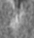


[case_idx=7] ID_0d0f361b_ID_17542973dc_s020_inst2  GT=SAH  VLM=NONE


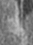


[case_idx=7] ID_0d0f361b_ID_17542973dc_s020_inst3  GT=SAH  VLM=NONE



[case_idx=7] ID_0d0f361b_ID_17542973dc_s020_inst4  GT=SAH  VLM=NONE



[case_idx=8] ID_0df4e645_ID_d14c8c9b99_s010_inst2  GT=SAH  VLM=NONE



[case_idx=8] ID_0df4e645_ID_d14c8c9b99_s010_inst3  GT=SAH  VLM=NONE



[case_idx=8] ID_0df4e645_ID_d14c8c9b99_s010_inst4  GT=SAH  VLM=IPH



[case_idx=8] ID_0df4e645_ID_d14c8c9b99_s011_inst1  GT=NONE  VLM=SDH



[case_idx=8] ID_0df4e645_ID_d14c8c9b99_s011_inst2  GT=NONE  VLM=SDH



[case_idx=8] ID_0df4e645_ID_d14c8c9b99_s011_inst4  GT=SAH  VLM=IPH



[case_idx=8] ID_0df4e645_ID_d14c8c9b99_s011_inst6  GT=SAH  VLM=IPH



[case_idx=8] ID_0df4e645_ID_d14c8c9b99_s012_inst2  GT=SAH  VLM=NONE


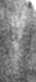


[case_idx=8] ID_0df4e645_ID_d14c8c9b99_s013_inst1  GT=SAH  VLM=NONE


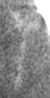


[case_idx=8] ID_0df4e645_ID_d14c8c9b99_s013_inst2  GT=IVH  VLM=NONE



[case_idx=8] ID_0df4e645_ID_d14c8c9b99_s014_inst1  GT=SAH  VLM=IPH


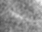


[case_idx=8] ID_0df4e645_ID_d14c8c9b99_s014_inst2  GT=SAH  VLM=NONE


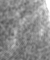


[case_idx=8] ID_0df4e645_ID_d14c8c9b99_s014_inst3  GT=SAH  VLM=IPH



[case_idx=8] ID_0df4e645_ID_d14c8c9b99_s014_inst4  GT=IVH  VLM=NONE



[case_idx=8] ID_0df4e645_ID_d14c8c9b99_s015_inst1  GT=SAH  VLM=NONE


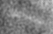


[case_idx=8] ID_0df4e645_ID_d14c8c9b99_s015_inst2  GT=SAH  VLM=NONE



[case_idx=8] ID_0df4e645_ID_d14c8c9b99_s015_inst5  GT=IVH  VLM=NONE



[case_idx=8] ID_0df4e645_ID_d14c8c9b99_s017_inst1  GT=SAH  VLM=NONE



[case_idx=9] ID_0e8ba35b_ID_d60ed297ea_s014_inst2  GT=IVH  VLM=IPH


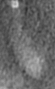


[case_idx=9] ID_0e8ba35b_ID_d60ed297ea_s014_inst3  GT=IVH  VLM=NONE


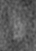


[case_idx=9] ID_0e8ba35b_ID_d60ed297ea_s015_inst1  GT=IPH  VLM=IVH


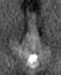


[case_idx=9] ID_0e8ba35b_ID_d60ed297ea_s015_inst3  GT=IVH  VLM=IPH


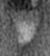


[case_idx=9] ID_0e8ba35b_ID_d60ed297ea_s016_inst1  GT=IVH  VLM=NONE


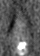


[case_idx=9] ID_0e8ba35b_ID_d60ed297ea_s016_inst3  GT=IVH  VLM=IPH


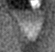


[case_idx=9] ID_0e8ba35b_ID_d60ed297ea_s017_inst2  GT=IVH  VLM=NONE


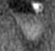


[case_idx=9] ID_0e8ba35b_ID_d60ed297ea_s018_inst1  GT=IVH  VLM=NONE


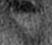


[case_idx=10] ID_0f320c56_ID_27f2bce652_s010_inst1  GT=SDH  VLM=NONE


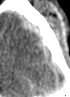


[case_idx=10] ID_0f320c56_ID_27f2bce652_s011_inst1  GT=SDH  VLM=NONE


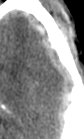


[case_idx=10] ID_0f320c56_ID_27f2bce652_s012_inst1  GT=SDH  VLM=NONE


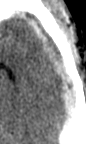


[case_idx=10] ID_0f320c56_ID_27f2bce652_s013_inst2  GT=IPH  VLM=SAH


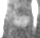


[case_idx=10] ID_0f320c56_ID_27f2bce652_s013_inst3  GT=SDH  VLM=NONE


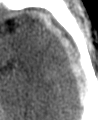


[case_idx=10] ID_0f320c56_ID_27f2bce652_s014_inst1  GT=SDH  VLM=NONE


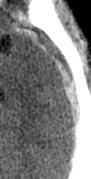


[case_idx=10] ID_0f320c56_ID_27f2bce652_s015_inst1  GT=SDH  VLM=NONE


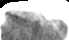


[case_idx=10] ID_0f320c56_ID_27f2bce652_s015_inst2  GT=SDH  VLM=NONE


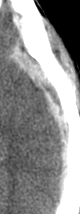


[case_idx=10] ID_0f320c56_ID_27f2bce652_s016_inst2  GT=SAH  VLM=NONE



[case_idx=10] ID_0f320c56_ID_27f2bce652_s017_inst2  GT=SAH  VLM=SDH



[case_idx=10] ID_0f320c56_ID_27f2bce652_s019_inst1  GT=SDH  VLM=EDH


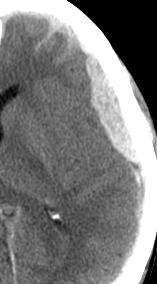


[case_idx=10] ID_0f320c56_ID_27f2bce652_s020_inst1  GT=SDH  VLM=EDH


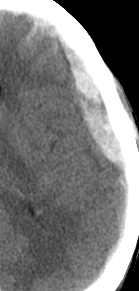


[case_idx=10] ID_0f320c56_ID_27f2bce652_s022_inst1  GT=NONE  VLM=SDH



[case_idx=10] ID_0f320c56_ID_27f2bce652_s024_inst4  GT=SDH  VLM=NONE


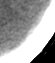


[case_idx=10] ID_0f320c56_ID_27f2bce652_s025_inst1  GT=NONE  VLM=SDH



[case_idx=10] ID_0f320c56_ID_27f2bce652_s027_inst1  GT=SDH  VLM=NONE


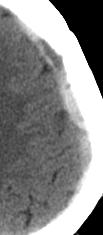


[case_idx=10] ID_0f320c56_ID_27f2bce652_s028_inst2  GT=NONE  VLM=SDH



[case_idx=10] ID_0f320c56_ID_27f2bce652_s029_inst1  GT=SDH  VLM=NONE


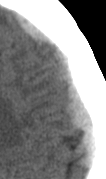


[case_idx=10] ID_0f320c56_ID_27f2bce652_s032_inst1  GT=SDH  VLM=NONE


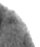


[case_idx=10] ID_0f320c56_ID_27f2bce652_s032_inst3  GT=SDH  VLM=NONE


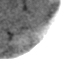


[case_idx=11] ID_0faab8a8_ID_df9d49e5e6_s012_inst1  GT=IPH  VLM=SDH


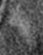


[case_idx=11] ID_0faab8a8_ID_df9d49e5e6_s013_inst2  GT=NONE  VLM=IPH



[case_idx=11] ID_0faab8a8_ID_df9d49e5e6_s015_inst1  GT=IPH  VLM=NONE


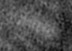


[case_idx=11] ID_0faab8a8_ID_df9d49e5e6_s016_inst1  GT=NONE  VLM=IPH



[case_idx=11] ID_0faab8a8_ID_df9d49e5e6_s017_inst1  GT=NONE  VLM=SDH



[case_idx=11] ID_0faab8a8_ID_df9d49e5e6_s017_inst2  GT=NONE  VLM=SDH



[case_idx=11] ID_0faab8a8_ID_df9d49e5e6_s017_inst3  GT=IVH  VLM=NONE



[case_idx=11] ID_0faab8a8_ID_df9d49e5e6_s019_inst1  GT=NONE  VLM=SAH


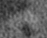


[case_idx=11] ID_0faab8a8_ID_df9d49e5e6_s020_inst1  GT=NONE  VLM=SDH


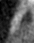


[case_idx=11] ID_0faab8a8_ID_df9d49e5e6_s022_inst1  GT=NONE  VLM=SDH



[case_idx=11] ID_0faab8a8_ID_df9d49e5e6_s022_inst2  GT=NONE  VLM=SDH



[case_idx=11] ID_0faab8a8_ID_df9d49e5e6_s023_inst1  GT=NONE  VLM=SDH


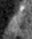


[case_idx=11] ID_0faab8a8_ID_df9d49e5e6_s024_inst1  GT=NONE  VLM=SDH


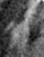


[case_idx=12] ID_0fb0d3d2_ID_6270e85cb5_s006_inst1  GT=IVH  VLM=NONE



[case_idx=12] ID_0fb0d3d2_ID_6270e85cb5_s007_inst1  GT=IVH  VLM=NONE


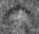


[case_idx=12] ID_0fb0d3d2_ID_6270e85cb5_s008_inst1  GT=IVH  VLM=NONE



[case_idx=12] ID_0fb0d3d2_ID_6270e85cb5_s009_inst1  GT=IVH  VLM=NONE



[case_idx=12] ID_0fb0d3d2_ID_6270e85cb5_s011_inst3  GT=IVH  VLM=NONE



[case_idx=12] ID_0fb0d3d2_ID_6270e85cb5_s012_inst2  GT=IVH  VLM=NONE



[case_idx=12] ID_0fb0d3d2_ID_6270e85cb5_s013_inst1  GT=IVH  VLM=NONE



[case_idx=13] ID_0ff437c4_ID_0c9a06814c_s015_inst1  GT=IPH  VLM=EDH


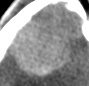


[case_idx=13] ID_0ff437c4_ID_0c9a06814c_s016_inst1  GT=IPH  VLM=EDH


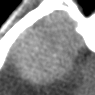


[case_idx=13] ID_0ff437c4_ID_0c9a06814c_s017_inst1  GT=IPH  VLM=SDH


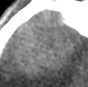


[case_idx=13] ID_0ff437c4_ID_0c9a06814c_s018_inst1  GT=IPH  VLM=NONE



[case_idx=14] ID_1aff4c26_ID_94bbe7f6cc_s006_inst1  GT=NONE  VLM=SAH


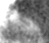


[case_idx=14] ID_1aff4c26_ID_94bbe7f6cc_s006_inst2  GT=NONE  VLM=SAH



[case_idx=14] ID_1aff4c26_ID_94bbe7f6cc_s006_inst3  GT=NONE  VLM=SAH



[case_idx=14] ID_1aff4c26_ID_94bbe7f6cc_s010_inst1  GT=IPH  VLM=NONE


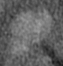


[case_idx=14] ID_1aff4c26_ID_94bbe7f6cc_s011_inst1  GT=IVH  VLM=IPH



[case_idx=14] ID_1aff4c26_ID_94bbe7f6cc_s011_inst2  GT=IVH  VLM=IPH



[case_idx=14] ID_1aff4c26_ID_94bbe7f6cc_s011_inst4  GT=IVH  VLM=IPH


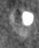


[case_idx=14] ID_1aff4c26_ID_94bbe7f6cc_s012_inst1  GT=IVH  VLM=IPH


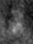


[case_idx=14] ID_1aff4c26_ID_94bbe7f6cc_s015_inst1  GT=IPH  VLM=NONE



[case_idx=14] ID_1aff4c26_ID_94bbe7f6cc_s015_inst2  GT=NONE  VLM=SDH


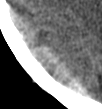


[case_idx=15] ID_1b5a3933_ID_856868cbfd_s013_inst1  GT=IPH  VLM=NONE


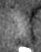


[case_idx=15] ID_1b5a3933_ID_856868cbfd_s014_inst1  GT=IPH  VLM=NONE


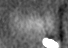


[case_idx=15] ID_1b5a3933_ID_856868cbfd_s016_inst1  GT=IPH  VLM=NONE


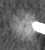


[case_idx=16] ID_1b5cfeda_ID_6e06ec9a1f_s008_inst1  GT=IPH  VLM=NONE


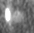


[case_idx=16] ID_1b5cfeda_ID_6e06ec9a1f_s009_inst1  GT=IPH  VLM=NONE



[case_idx=16] ID_1b5cfeda_ID_6e06ec9a1f_s009_inst2  GT=NONE  VLM=SAH



[case_idx=16] ID_1b5cfeda_ID_6e06ec9a1f_s009_inst3  GT=NONE  VLM=SAH



[case_idx=16] ID_1b5cfeda_ID_6e06ec9a1f_s010_inst1  GT=SDH  VLM=NONE


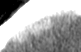


[case_idx=16] ID_1b5cfeda_ID_6e06ec9a1f_s010_inst2  GT=SDH  VLM=NONE



[case_idx=16] ID_1b5cfeda_ID_6e06ec9a1f_s011_inst2  GT=SDH  VLM=SAH



[case_idx=16] ID_1b5cfeda_ID_6e06ec9a1f_s013_inst2  GT=SDH  VLM=NONE


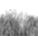


[case_idx=16] ID_1b5cfeda_ID_6e06ec9a1f_s013_inst5  GT=SDH  VLM=NONE



[case_idx=16] ID_1b5cfeda_ID_6e06ec9a1f_s014_inst1  GT=SDH  VLM=SAH


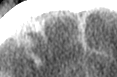


[case_idx=16] ID_1b5cfeda_ID_6e06ec9a1f_s014_inst3  GT=NONE  VLM=SAH



[case_idx=16] ID_1b5cfeda_ID_6e06ec9a1f_s014_inst4  GT=NONE  VLM=SAH



[case_idx=16] ID_1b5cfeda_ID_6e06ec9a1f_s014_inst5  GT=NONE  VLM=SAH



[case_idx=16] ID_1b5cfeda_ID_6e06ec9a1f_s014_inst6  GT=SDH  VLM=SAH



[case_idx=16] ID_1b5cfeda_ID_6e06ec9a1f_s015_inst2  GT=SAH  VLM=SDH



[case_idx=16] ID_1b5cfeda_ID_6e06ec9a1f_s015_inst4  GT=NONE  VLM=SDH



[case_idx=16] ID_1b5cfeda_ID_6e06ec9a1f_s016_inst2  GT=SDH  VLM=SAH



[case_idx=16] ID_1b5cfeda_ID_6e06ec9a1f_s016_inst3  GT=SDH  VLM=SAH


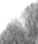


[case_idx=16] ID_1b5cfeda_ID_6e06ec9a1f_s016_inst4  GT=SAH  VLM=NONE



[case_idx=16] ID_1b5cfeda_ID_6e06ec9a1f_s016_inst5  GT=SDH  VLM=NONE



[case_idx=16] ID_1b5cfeda_ID_6e06ec9a1f_s017_inst1  GT=SDH  VLM=SAH



[case_idx=16] ID_1b5cfeda_ID_6e06ec9a1f_s017_inst2  GT=SAH  VLM=NONE



[case_idx=16] ID_1b5cfeda_ID_6e06ec9a1f_s017_inst3  GT=SDH  VLM=EDH



[case_idx=16] ID_1b5cfeda_ID_6e06ec9a1f_s018_inst1  GT=SAH  VLM=SDH


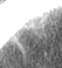


[case_idx=16] ID_1b5cfeda_ID_6e06ec9a1f_s019_inst1  GT=SAH  VLM=SDH


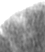


[case_idx=16] ID_1b5cfeda_ID_6e06ec9a1f_s019_inst2  GT=SAH  VLM=NONE


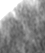


[case_idx=16] ID_1b5cfeda_ID_6e06ec9a1f_s019_inst4  GT=SAH  VLM=NONE



[case_idx=16] ID_1b5cfeda_ID_6e06ec9a1f_s020_inst1  GT=SAH  VLM=NONE


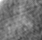


[case_idx=16] ID_1b5cfeda_ID_6e06ec9a1f_s020_inst2  GT=NONE  VLM=SDH



[case_idx=16] ID_1b5cfeda_ID_6e06ec9a1f_s020_inst3  GT=SAH  VLM=NONE



[case_idx=16] ID_1b5cfeda_ID_6e06ec9a1f_s020_inst4  GT=NONE  VLM=SDH



[case_idx=16] ID_1b5cfeda_ID_6e06ec9a1f_s021_inst1  GT=SAH  VLM=SDH


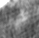


[case_idx=16] ID_1b5cfeda_ID_6e06ec9a1f_s021_inst2  GT=SAH  VLM=NONE


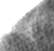


[case_idx=16] ID_1b5cfeda_ID_6e06ec9a1f_s022_inst1  GT=NONE  VLM=SAH



[case_idx=16] ID_1b5cfeda_ID_6e06ec9a1f_s022_inst2  GT=NONE  VLM=IPH



[case_idx=16] ID_1b5cfeda_ID_6e06ec9a1f_s022_inst4  GT=SAH  VLM=NONE


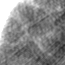


[case_idx=16] ID_1b5cfeda_ID_6e06ec9a1f_s023_inst1  GT=SAH  VLM=IPH


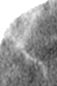


[case_idx=16] ID_1b5cfeda_ID_6e06ec9a1f_s025_inst4  GT=SAH  VLM=IPH



[case_idx=17] ID_1bd90426_ID_44493c1d26_s014_inst1  GT=SAH  VLM=NONE


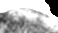


[case_idx=17] ID_1bd90426_ID_44493c1d26_s014_inst2  GT=SAH  VLM=NONE


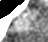


[case_idx=17] ID_1bd90426_ID_44493c1d26_s015_inst1  GT=SAH  VLM=NONE



[case_idx=17] ID_1bd90426_ID_44493c1d26_s015_inst2  GT=SAH  VLM=NONE


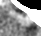


[case_idx=17] ID_1bd90426_ID_44493c1d26_s015_inst3  GT=SAH  VLM=NONE


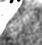


[case_idx=17] ID_1bd90426_ID_44493c1d26_s016_inst2  GT=SAH  VLM=IPH


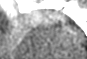


[case_idx=17] ID_1bd90426_ID_44493c1d26_s019_inst2  GT=NONE  VLM=SAH



[case_idx=17] ID_1bd90426_ID_44493c1d26_s019_inst3  GT=NONE  VLM=SAH



[case_idx=17] ID_1bd90426_ID_44493c1d26_s020_inst2  GT=SAH  VLM=NONE


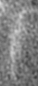


[case_idx=17] ID_1bd90426_ID_44493c1d26_s021_inst1  GT=SAH  VLM=NONE


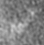


[case_idx=17] ID_1bd90426_ID_44493c1d26_s021_inst3  GT=SAH  VLM=NONE


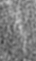


[case_idx=17] ID_1bd90426_ID_44493c1d26_s021_inst4  GT=SAH  VLM=IPH


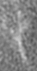


[case_idx=17] ID_1bd90426_ID_44493c1d26_s022_inst1  GT=SAH  VLM=NONE


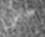


[case_idx=17] ID_1bd90426_ID_44493c1d26_s022_inst2  GT=SAH  VLM=NONE



[case_idx=17] ID_1bd90426_ID_44493c1d26_s022_inst3  GT=SAH  VLM=NONE



[case_idx=17] ID_1bd90426_ID_44493c1d26_s022_inst4  GT=SAH  VLM=NONE



[case_idx=17] ID_1bd90426_ID_44493c1d26_s025_inst1  GT=SAH  VLM=NONE



[case_idx=17] ID_1bd90426_ID_44493c1d26_s031_inst1  GT=SAH  VLM=NONE



[case_idx=18] ID_1c3da1cd_ID_cbb8a2936b_s009_inst1  GT=IVH  VLM=NONE


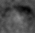


[case_idx=18] ID_1c3da1cd_ID_cbb8a2936b_s010_inst1  GT=IVH  VLM=NONE


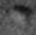


[case_idx=18] ID_1c3da1cd_ID_cbb8a2936b_s013_inst1  GT=SDH  VLM=NONE



[case_idx=18] ID_1c3da1cd_ID_cbb8a2936b_s013_inst2  GT=SAH  VLM=NONE


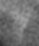


[case_idx=18] ID_1c3da1cd_ID_cbb8a2936b_s013_inst3  GT=IVH  VLM=NONE



[case_idx=18] ID_1c3da1cd_ID_cbb8a2936b_s014_inst2  GT=SAH  VLM=NONE


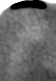


[case_idx=18] ID_1c3da1cd_ID_cbb8a2936b_s014_inst3  GT=SAH  VLM=NONE


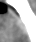


[case_idx=18] ID_1c3da1cd_ID_cbb8a2936b_s014_inst4  GT=SAH  VLM=NONE


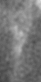


[case_idx=18] ID_1c3da1cd_ID_cbb8a2936b_s014_inst6  GT=IVH  VLM=NONE



[case_idx=18] ID_1c3da1cd_ID_cbb8a2936b_s014_inst7  GT=IVH  VLM=NONE


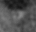


[case_idx=18] ID_1c3da1cd_ID_cbb8a2936b_s015_inst2  GT=SAH  VLM=NONE


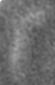


[case_idx=18] ID_1c3da1cd_ID_cbb8a2936b_s015_inst3  GT=SAH  VLM=NONE



[case_idx=18] ID_1c3da1cd_ID_cbb8a2936b_s015_inst5  GT=IVH  VLM=NONE



[case_idx=18] ID_1c3da1cd_ID_cbb8a2936b_s015_inst6  GT=IVH  VLM=NONE



[case_idx=18] ID_1c3da1cd_ID_cbb8a2936b_s015_inst7  GT=SDH  VLM=NONE



[case_idx=18] ID_1c3da1cd_ID_cbb8a2936b_s016_inst1  GT=SDH  VLM=NONE



[case_idx=18] ID_1c3da1cd_ID_cbb8a2936b_s016_inst3  GT=SDH  VLM=NONE


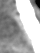


[case_idx=18] ID_1c3da1cd_ID_cbb8a2936b_s016_inst4  GT=SAH  VLM=NONE



[case_idx=18] ID_1c3da1cd_ID_cbb8a2936b_s016_inst6  GT=SAH  VLM=NONE



[case_idx=18] ID_1c3da1cd_ID_cbb8a2936b_s016_inst7  GT=SAH  VLM=NONE



[case_idx=18] ID_1c3da1cd_ID_cbb8a2936b_s016_inst8  GT=SAH  VLM=IPH


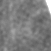


[case_idx=18] ID_1c3da1cd_ID_cbb8a2936b_s016_inst9  GT=SAH  VLM=NONE


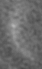


[case_idx=18] ID_1c3da1cd_ID_cbb8a2936b_s016_inst10  GT=SAH  VLM=IPH


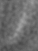


[case_idx=18] ID_1c3da1cd_ID_cbb8a2936b_s016_inst11  GT=SAH  VLM=NONE


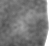


[case_idx=18] ID_1c3da1cd_ID_cbb8a2936b_s016_inst12  GT=IVH  VLM=NONE



[case_idx=18] ID_1c3da1cd_ID_cbb8a2936b_s016_inst13  GT=IVH  VLM=NONE



[case_idx=18] ID_1c3da1cd_ID_cbb8a2936b_s016_inst14  GT=SDH  VLM=SAH



[case_idx=18] ID_1c3da1cd_ID_cbb8a2936b_s017_inst1  GT=SDH  VLM=NONE


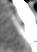


[case_idx=18] ID_1c3da1cd_ID_cbb8a2936b_s017_inst5  GT=SAH  VLM=NONE


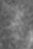


[case_idx=18] ID_1c3da1cd_ID_cbb8a2936b_s017_inst6  GT=SAH  VLM=NONE


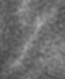


[case_idx=18] ID_1c3da1cd_ID_cbb8a2936b_s017_inst7  GT=SAH  VLM=NONE


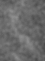


[case_idx=18] ID_1c3da1cd_ID_cbb8a2936b_s017_inst8  GT=SAH  VLM=NONE



[case_idx=18] ID_1c3da1cd_ID_cbb8a2936b_s017_inst9  GT=SAH  VLM=NONE


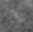


[case_idx=18] ID_1c3da1cd_ID_cbb8a2936b_s017_inst10  GT=SAH  VLM=NONE



[case_idx=18] ID_1c3da1cd_ID_cbb8a2936b_s017_inst12  GT=IVH  VLM=NONE



[case_idx=18] ID_1c3da1cd_ID_cbb8a2936b_s017_inst14  GT=SDH  VLM=NONE



[case_idx=18] ID_1c3da1cd_ID_cbb8a2936b_s018_inst2  GT=SDH  VLM=NONE



[case_idx=18] ID_1c3da1cd_ID_cbb8a2936b_s018_inst3  GT=SAH  VLM=NONE


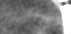


[case_idx=18] ID_1c3da1cd_ID_cbb8a2936b_s018_inst4  GT=SAH  VLM=IPH


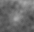


[case_idx=18] ID_1c3da1cd_ID_cbb8a2936b_s018_inst5  GT=SAH  VLM=IPH


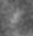


[case_idx=18] ID_1c3da1cd_ID_cbb8a2936b_s018_inst6  GT=SAH  VLM=NONE


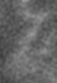


[case_idx=18] ID_1c3da1cd_ID_cbb8a2936b_s018_inst7  GT=SAH  VLM=IPH



[case_idx=18] ID_1c3da1cd_ID_cbb8a2936b_s018_inst8  GT=SAH  VLM=IPH



[case_idx=18] ID_1c3da1cd_ID_cbb8a2936b_s018_inst9  GT=SAH  VLM=IPH


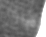


[case_idx=18] ID_1c3da1cd_ID_cbb8a2936b_s019_inst1  GT=SDH  VLM=NONE


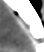


[case_idx=18] ID_1c3da1cd_ID_cbb8a2936b_s019_inst3  GT=SAH  VLM=NONE



[case_idx=18] ID_1c3da1cd_ID_cbb8a2936b_s019_inst4  GT=SAH  VLM=NONE



[case_idx=18] ID_1c3da1cd_ID_cbb8a2936b_s019_inst5  GT=SAH  VLM=NONE



[case_idx=18] ID_1c3da1cd_ID_cbb8a2936b_s019_inst6  GT=SAH  VLM=NONE



[case_idx=18] ID_1c3da1cd_ID_cbb8a2936b_s020_inst3  GT=SDH  VLM=NONE



[case_idx=18] ID_1c3da1cd_ID_cbb8a2936b_s020_inst4  GT=SAH  VLM=NONE



[case_idx=18] ID_1c3da1cd_ID_cbb8a2936b_s020_inst5  GT=SAH  VLM=IPH



[case_idx=18] ID_1c3da1cd_ID_cbb8a2936b_s020_inst7  GT=SAH  VLM=NONE


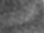


[case_idx=18] ID_1c3da1cd_ID_cbb8a2936b_s020_inst8  GT=SAH  VLM=NONE


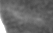


[case_idx=18] ID_1c3da1cd_ID_cbb8a2936b_s021_inst1  GT=SAH  VLM=IPH


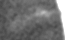


[case_idx=18] ID_1c3da1cd_ID_cbb8a2936b_s021_inst2  GT=SAH  VLM=NONE


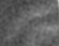


[case_idx=18] ID_1c3da1cd_ID_cbb8a2936b_s021_inst3  GT=SAH  VLM=NONE



[case_idx=18] ID_1c3da1cd_ID_cbb8a2936b_s021_inst4  GT=SAH  VLM=NONE



[case_idx=18] ID_1c3da1cd_ID_cbb8a2936b_s022_inst2  GT=SAH  VLM=NONE


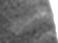


[case_idx=18] ID_1c3da1cd_ID_cbb8a2936b_s022_inst3  GT=SAH  VLM=NONE



[case_idx=18] ID_1c3da1cd_ID_cbb8a2936b_s022_inst5  GT=SAH  VLM=NONE



[case_idx=18] ID_1c3da1cd_ID_cbb8a2936b_s022_inst6  GT=SAH  VLM=NONE



[case_idx=18] ID_1c3da1cd_ID_cbb8a2936b_s022_inst7  GT=SAH  VLM=NONE



[case_idx=18] ID_1c3da1cd_ID_cbb8a2936b_s023_inst1  GT=SAH  VLM=NONE



[case_idx=18] ID_1c3da1cd_ID_cbb8a2936b_s023_inst2  GT=SAH  VLM=NONE



[case_idx=18] ID_1c3da1cd_ID_cbb8a2936b_s023_inst3  GT=SAH  VLM=NONE


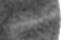


[case_idx=18] ID_1c3da1cd_ID_cbb8a2936b_s023_inst4  GT=SAH  VLM=NONE



[case_idx=18] ID_1c3da1cd_ID_cbb8a2936b_s023_inst5  GT=SAH  VLM=NONE



[case_idx=18] ID_1c3da1cd_ID_cbb8a2936b_s023_inst6  GT=SAH  VLM=NONE



[case_idx=18] ID_1c3da1cd_ID_cbb8a2936b_s024_inst3  GT=NONE  VLM=IPH



[case_idx=18] ID_1c3da1cd_ID_cbb8a2936b_s024_inst4  GT=SAH  VLM=NONE


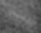


[case_idx=18] ID_1c3da1cd_ID_cbb8a2936b_s024_inst6  GT=SAH  VLM=IPH


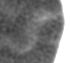


[case_idx=18] ID_1c3da1cd_ID_cbb8a2936b_s024_inst7  GT=SAH  VLM=NONE


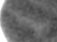


[case_idx=18] ID_1c3da1cd_ID_cbb8a2936b_s024_inst9  GT=SDH  VLM=NONE



[case_idx=18] ID_1c3da1cd_ID_cbb8a2936b_s025_inst1  GT=SAH  VLM=NONE


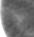


[case_idx=18] ID_1c3da1cd_ID_cbb8a2936b_s025_inst2  GT=SAH  VLM=NONE


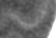


[case_idx=18] ID_1c3da1cd_ID_cbb8a2936b_s025_inst3  GT=SAH  VLM=NONE


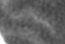


[case_idx=18] ID_1c3da1cd_ID_cbb8a2936b_s026_inst2  GT=SAH  VLM=NONE


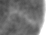


[case_idx=18] ID_1c3da1cd_ID_cbb8a2936b_s026_inst3  GT=SAH  VLM=NONE


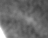


[case_idx=19] ID_1dfa5b21_ID_02cd74218f_s012_inst2  GT=NONE  VLM=EDH



[case_idx=19] ID_1dfa5b21_ID_02cd74218f_s016_inst1  GT=IPH  VLM=NONE


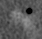


[case_idx=19] ID_1dfa5b21_ID_02cd74218f_s019_inst1  GT=IPH  VLM=NONE



[case_idx=21] ID_1ea8a377_ID_38c12664cf_s009_inst1  GT=SDH  VLM=NONE


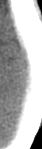


[case_idx=21] ID_1ea8a377_ID_38c12664cf_s010_inst1  GT=SDH  VLM=NONE


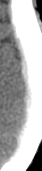


[case_idx=21] ID_1ea8a377_ID_38c12664cf_s011_inst1  GT=SDH  VLM=NONE


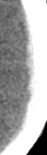


[case_idx=21] ID_1ea8a377_ID_38c12664cf_s012_inst1  GT=SDH  VLM=NONE


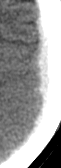


[case_idx=21] ID_1ea8a377_ID_38c12664cf_s013_inst2  GT=NONE  VLM=IPH


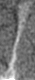


[case_idx=21] ID_1ea8a377_ID_38c12664cf_s019_inst2  GT=SAH  VLM=SDH



[case_idx=21] ID_1ea8a377_ID_38c12664cf_s021_inst1  GT=SDH  VLM=NONE


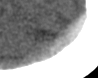


[case_idx=21] ID_1ea8a377_ID_38c12664cf_s022_inst1  GT=SDH  VLM=NONE


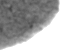


[case_idx=22] ID_1f2017cd_ID_bfab570858_s008_inst1  GT=IPH  VLM=SAH


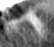


[case_idx=22] ID_1f2017cd_ID_bfab570858_s009_inst1  GT=IPH  VLM=SAH


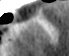


[case_idx=22] ID_1f2017cd_ID_bfab570858_s011_inst1  GT=SDH  VLM=EDH


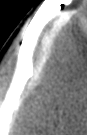


[case_idx=22] ID_1f2017cd_ID_bfab570858_s011_inst2  GT=IPH  VLM=SDH


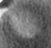


[case_idx=22] ID_1f2017cd_ID_bfab570858_s012_inst1  GT=SDH  VLM=EDH


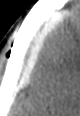


[case_idx=22] ID_1f2017cd_ID_bfab570858_s013_inst1  GT=SDH  VLM=EDH


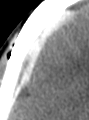


[case_idx=22] ID_1f2017cd_ID_bfab570858_s015_inst1  GT=SDH  VLM=NONE



[case_idx=22] ID_1f2017cd_ID_bfab570858_s015_inst2  GT=SDH  VLM=EDH


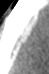


[case_idx=22] ID_1f2017cd_ID_bfab570858_s018_inst1  GT=SDH  VLM=NONE



[case_idx=23] ID_1fcb892c_ID_908ec8ac6e_s006_inst1  GT=IVH  VLM=NONE



[case_idx=23] ID_1fcb892c_ID_908ec8ac6e_s007_inst1  GT=IVH  VLM=NONE



[case_idx=23] ID_1fcb892c_ID_908ec8ac6e_s013_inst2  GT=IVH  VLM=IPH



[case_idx=23] ID_1fcb892c_ID_908ec8ac6e_s014_inst3  GT=NONE  VLM=IVH


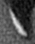


[case_idx=23] ID_1fcb892c_ID_908ec8ac6e_s016_inst2  GT=IVH  VLM=IPH



[case_idx=23] ID_1fcb892c_ID_908ec8ac6e_s020_inst2  GT=NONE  VLM=IPH



[case_idx=24] ID_26aa5747_ID_da121424ef_s013_inst1  GT=IVH  VLM=NONE



[case_idx=24] ID_26aa5747_ID_da121424ef_s014_inst3  GT=IVH  VLM=NONE


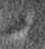


[case_idx=24] ID_26aa5747_ID_da121424ef_s015_inst1  GT=IVH  VLM=IPH



[case_idx=24] ID_26aa5747_ID_da121424ef_s015_inst2  GT=IVH  VLM=IPH



[case_idx=24] ID_26aa5747_ID_da121424ef_s015_inst4  GT=IVH  VLM=IPH


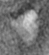


[case_idx=24] ID_26aa5747_ID_da121424ef_s016_inst1  GT=IVH  VLM=IPH


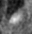


[case_idx=24] ID_26aa5747_ID_da121424ef_s016_inst3  GT=IVH  VLM=NONE



[case_idx=24] ID_26aa5747_ID_da121424ef_s017_inst3  GT=IVH  VLM=IPH



[case_idx=24] ID_26aa5747_ID_da121424ef_s018_inst2  GT=IVH  VLM=IPH


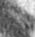


[case_idx=24] ID_26aa5747_ID_da121424ef_s018_inst3  GT=IVH  VLM=IPH



[case_idx=24] ID_26aa5747_ID_da121424ef_s019_inst2  GT=NONE  VLM=IPH



[case_idx=25] ID_28e80c22_ID_bf9876ebdd_s011_inst1  GT=IPH  VLM=NONE


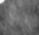


[case_idx=25] ID_28e80c22_ID_bf9876ebdd_s014_inst2  GT=SDH  VLM=NONE


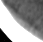


[case_idx=26] ID_2b7cc24e_ID_6fea1c1fb3_s009_inst1  GT=EDH  VLM=NONE



[case_idx=26] ID_2b7cc24e_ID_6fea1c1fb3_s010_inst1  GT=EDH  VLM=SDH


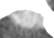


[case_idx=26] ID_2b7cc24e_ID_6fea1c1fb3_s011_inst1  GT=EDH  VLM=NONE


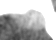


[case_idx=26] ID_2b7cc24e_ID_6fea1c1fb3_s012_inst1  GT=EDH  VLM=NONE


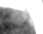


[case_idx=26] ID_2b7cc24e_ID_6fea1c1fb3_s015_inst1  GT=SDH  VLM=NONE



[case_idx=26] ID_2b7cc24e_ID_6fea1c1fb3_s016_inst1  GT=SDH  VLM=NONE



[case_idx=26] ID_2b7cc24e_ID_6fea1c1fb3_s016_inst2  GT=SDH  VLM=NONE



[case_idx=26] ID_2b7cc24e_ID_6fea1c1fb3_s016_inst3  GT=NONE  VLM=IPH



[case_idx=26] ID_2b7cc24e_ID_6fea1c1fb3_s017_inst1  GT=SDH  VLM=NONE


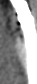


[case_idx=26] ID_2b7cc24e_ID_6fea1c1fb3_s018_inst1  GT=SDH  VLM=NONE


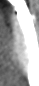


[case_idx=26] ID_2b7cc24e_ID_6fea1c1fb3_s020_inst1  GT=SDH  VLM=EDH


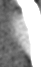


[case_idx=26] ID_2b7cc24e_ID_6fea1c1fb3_s021_inst1  GT=SDH  VLM=NONE


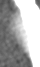


[case_idx=27] ID_3aa50c55_ID_9bed05390d_s008_inst1  GT=SAH  VLM=NONE


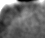


[case_idx=27] ID_3aa50c55_ID_9bed05390d_s009_inst1  GT=SAH  VLM=NONE



[case_idx=27] ID_3aa50c55_ID_9bed05390d_s009_inst2  GT=SAH  VLM=NONE



[case_idx=27] ID_3aa50c55_ID_9bed05390d_s010_inst1  GT=NONE  VLM=SAH



[case_idx=27] ID_3aa50c55_ID_9bed05390d_s010_inst5  GT=SAH  VLM=NONE



[case_idx=27] ID_3aa50c55_ID_9bed05390d_s010_inst6  GT=NONE  VLM=SAH



[case_idx=27] ID_3aa50c55_ID_9bed05390d_s011_inst1  GT=SAH  VLM=NONE



[case_idx=27] ID_3aa50c55_ID_9bed05390d_s011_inst2  GT=SAH  VLM=NONE



[case_idx=27] ID_3aa50c55_ID_9bed05390d_s011_inst3  GT=SAH  VLM=IPH


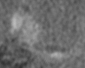


[case_idx=27] ID_3aa50c55_ID_9bed05390d_s011_inst6  GT=SAH  VLM=NONE


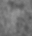


[case_idx=27] ID_3aa50c55_ID_9bed05390d_s012_inst3  GT=SAH  VLM=IPH


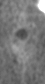


[case_idx=27] ID_3aa50c55_ID_9bed05390d_s012_inst5  GT=SAH  VLM=NONE



[case_idx=27] ID_3aa50c55_ID_9bed05390d_s012_inst6  GT=SAH  VLM=NONE


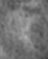


[case_idx=27] ID_3aa50c55_ID_9bed05390d_s012_inst7  GT=NONE  VLM=SAH



[case_idx=27] ID_3aa50c55_ID_9bed05390d_s012_inst9  GT=SAH  VLM=IPH



[case_idx=27] ID_3aa50c55_ID_9bed05390d_s013_inst4  GT=SAH  VLM=NONE


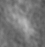


[case_idx=27] ID_3aa50c55_ID_9bed05390d_s014_inst2  GT=SAH  VLM=NONE



[case_idx=27] ID_3aa50c55_ID_9bed05390d_s014_inst3  GT=SAH  VLM=NONE


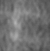


[case_idx=27] ID_3aa50c55_ID_9bed05390d_s014_inst4  GT=NONE  VLM=IPH



[case_idx=27] ID_3aa50c55_ID_9bed05390d_s014_inst5  GT=SAH  VLM=IPH


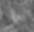


[case_idx=27] ID_3aa50c55_ID_9bed05390d_s014_inst6  GT=SAH  VLM=NONE


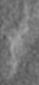


[case_idx=27] ID_3aa50c55_ID_9bed05390d_s014_inst7  GT=SAH  VLM=IPH


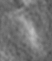


[case_idx=27] ID_3aa50c55_ID_9bed05390d_s015_inst1  GT=SAH  VLM=SDH


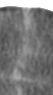


[case_idx=27] ID_3aa50c55_ID_9bed05390d_s015_inst2  GT=SAH  VLM=NONE



[case_idx=27] ID_3aa50c55_ID_9bed05390d_s015_inst3  GT=SAH  VLM=IPH



[case_idx=27] ID_3aa50c55_ID_9bed05390d_s015_inst4  GT=SAH  VLM=NONE



[case_idx=27] ID_3aa50c55_ID_9bed05390d_s015_inst5  GT=SAH  VLM=NONE


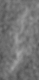


[case_idx=27] ID_3aa50c55_ID_9bed05390d_s015_inst6  GT=SAH  VLM=IPH


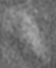


[case_idx=27] ID_3aa50c55_ID_9bed05390d_s016_inst3  GT=SAH  VLM=NONE


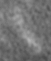


[case_idx=27] ID_3aa50c55_ID_9bed05390d_s016_inst5  GT=SAH  VLM=NONE


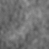


[case_idx=27] ID_3aa50c55_ID_9bed05390d_s016_inst6  GT=NONE  VLM=SAH



[case_idx=27] ID_3aa50c55_ID_9bed05390d_s016_inst8  GT=IVH  VLM=NONE



[case_idx=27] ID_3aa50c55_ID_9bed05390d_s016_inst9  GT=SAH  VLM=NONE



[case_idx=27] ID_3aa50c55_ID_9bed05390d_s017_inst2  GT=SAH  VLM=IPH



[case_idx=27] ID_3aa50c55_ID_9bed05390d_s017_inst3  GT=SAH  VLM=NONE



[case_idx=27] ID_3aa50c55_ID_9bed05390d_s017_inst4  GT=SAH  VLM=NONE


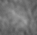


[case_idx=27] ID_3aa50c55_ID_9bed05390d_s017_inst5  GT=SAH  VLM=NONE



[case_idx=27] ID_3aa50c55_ID_9bed05390d_s017_inst6  GT=IVH  VLM=NONE



[case_idx=27] ID_3aa50c55_ID_9bed05390d_s018_inst1  GT=SAH  VLM=NONE


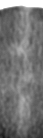


[case_idx=27] ID_3aa50c55_ID_9bed05390d_s018_inst2  GT=SAH  VLM=NONE



[case_idx=27] ID_3aa50c55_ID_9bed05390d_s018_inst3  GT=SAH  VLM=NONE



[case_idx=27] ID_3aa50c55_ID_9bed05390d_s019_inst1  GT=SAH  VLM=SDH


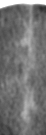


[case_idx=27] ID_3aa50c55_ID_9bed05390d_s019_inst2  GT=NONE  VLM=SAH



[case_idx=27] ID_3aa50c55_ID_9bed05390d_s019_inst3  GT=SAH  VLM=IPH


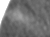


[case_idx=27] ID_3aa50c55_ID_9bed05390d_s019_inst4  GT=SAH  VLM=NONE



[case_idx=27] ID_3aa50c55_ID_9bed05390d_s020_inst1  GT=SAH  VLM=SDH


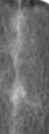


[case_idx=27] ID_3aa50c55_ID_9bed05390d_s020_inst2  GT=NONE  VLM=SAH


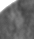


[case_idx=27] ID_3aa50c55_ID_9bed05390d_s020_inst3  GT=SAH  VLM=NONE



[case_idx=27] ID_3aa50c55_ID_9bed05390d_s021_inst2  GT=NONE  VLM=SAH



[case_idx=27] ID_3aa50c55_ID_9bed05390d_s021_inst6  GT=NONE  VLM=SAH



[case_idx=27] ID_3aa50c55_ID_9bed05390d_s021_inst7  GT=NONE  VLM=SAH



[case_idx=27] ID_3aa50c55_ID_9bed05390d_s022_inst6  GT=NONE  VLM=SAH


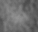


[case_idx=27] ID_3aa50c55_ID_9bed05390d_s022_inst10  GT=SAH  VLM=NONE



[case_idx=27] ID_3aa50c55_ID_9bed05390d_s023_inst1  GT=SAH  VLM=IPH


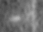


[case_idx=27] ID_3aa50c55_ID_9bed05390d_s023_inst2  GT=SAH  VLM=IPH


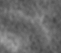


[case_idx=27] ID_3aa50c55_ID_9bed05390d_s023_inst3  GT=SAH  VLM=IPH


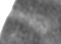


[case_idx=27] ID_3aa50c55_ID_9bed05390d_s023_inst4  GT=NONE  VLM=SAH



[case_idx=27] ID_3aa50c55_ID_9bed05390d_s023_inst8  GT=SAH  VLM=NONE


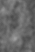


[case_idx=27] ID_3aa50c55_ID_9bed05390d_s024_inst1  GT=SAH  VLM=IPH



[case_idx=27] ID_3aa50c55_ID_9bed05390d_s024_inst2  GT=SAH  VLM=NONE


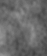


[case_idx=27] ID_3aa50c55_ID_9bed05390d_s024_inst3  GT=SAH  VLM=IPH


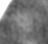


[case_idx=27] ID_3aa50c55_ID_9bed05390d_s024_inst4  GT=SAH  VLM=NONE


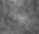


[case_idx=27] ID_3aa50c55_ID_9bed05390d_s024_inst5  GT=SAH  VLM=IPH



[case_idx=27] ID_3aa50c55_ID_9bed05390d_s024_inst6  GT=SAH  VLM=IPH



[case_idx=27] ID_3aa50c55_ID_9bed05390d_s024_inst7  GT=SAH  VLM=IPH



[case_idx=27] ID_3aa50c55_ID_9bed05390d_s025_inst1  GT=SAH  VLM=NONE


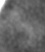


[case_idx=27] ID_3aa50c55_ID_9bed05390d_s025_inst2  GT=SAH  VLM=IPH


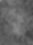


[case_idx=27] ID_3aa50c55_ID_9bed05390d_s025_inst3  GT=SAH  VLM=NONE



[case_idx=27] ID_3aa50c55_ID_9bed05390d_s026_inst1  GT=SAH  VLM=NONE



[case_idx=27] ID_3aa50c55_ID_9bed05390d_s026_inst2  GT=SAH  VLM=NONE


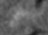


[case_idx=28] ID_3fa11bf9_ID_9a7a61f482_s014_inst1  GT=IVH  VLM=IPH


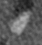


[case_idx=28] ID_3fa11bf9_ID_9a7a61f482_s015_inst1  GT=IVH  VLM=NONE


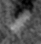


[case_idx=29] ID_3fd996e7_ID_3d4c47c7a4_s008_inst1  GT=NONE  VLM=IPH


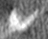


[case_idx=29] ID_3fd996e7_ID_3d4c47c7a4_s011_inst3  GT=SDH  VLM=NONE


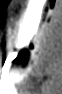


[case_idx=29] ID_3fd996e7_ID_3d4c47c7a4_s012_inst5  GT=SDH  VLM=NONE


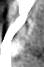


[case_idx=29] ID_3fd996e7_ID_3d4c47c7a4_s014_inst2  GT=IVH  VLM=IPH



[case_idx=30] ID_4df69bae_ID_e5bd3504d8_s010_inst1  GT=SDH  VLM=NONE


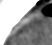


[case_idx=30] ID_4df69bae_ID_e5bd3504d8_s011_inst1  GT=SDH  VLM=NONE


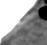


[case_idx=30] ID_4df69bae_ID_e5bd3504d8_s012_inst1  GT=SDH  VLM=NONE



[case_idx=30] ID_4df69bae_ID_e5bd3504d8_s015_inst2  GT=SDH  VLM=NONE


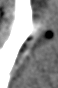


[case_idx=30] ID_4df69bae_ID_e5bd3504d8_s016_inst1  GT=NONE  VLM=SDH



[case_idx=30] ID_4df69bae_ID_e5bd3504d8_s016_inst2  GT=SDH  VLM=EDH


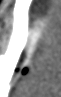


[case_idx=30] ID_4df69bae_ID_e5bd3504d8_s017_inst1  GT=SDH  VLM=EDH


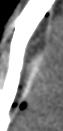


[case_idx=30] ID_4df69bae_ID_e5bd3504d8_s018_inst1  GT=SDH  VLM=NONE


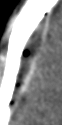


[case_idx=30] ID_4df69bae_ID_e5bd3504d8_s019_inst1  GT=SDH  VLM=NONE


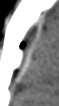


[case_idx=30] ID_4df69bae_ID_e5bd3504d8_s020_inst1  GT=SDH  VLM=EDH


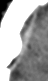


[case_idx=31] ID_4e970d93_ID_2713bc273b_s019_inst1  GT=SDH  VLM=NONE


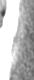


[case_idx=31] ID_4e970d93_ID_2713bc273b_s028_inst2  GT=SDH  VLM=NONE


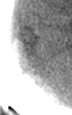


[case_idx=32] ID_5ae36db5_ID_17014b11f1_s007_inst1  GT=IPH  VLM=NONE


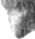


[case_idx=32] ID_5ae36db5_ID_17014b11f1_s008_inst1  GT=IPH  VLM=SDH


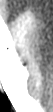


[case_idx=32] ID_5ae36db5_ID_17014b11f1_s009_inst1  GT=IPH  VLM=SDH


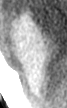


[case_idx=33] ID_5fe1b289_ID_0f30dec3b3_s016_inst1  GT=EDH  VLM=NONE



[case_idx=33] ID_5fe1b289_ID_0f30dec3b3_s017_inst1  GT=EDH  VLM=SDH


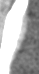


[case_idx=33] ID_5fe1b289_ID_0f30dec3b3_s018_inst1  GT=EDH  VLM=SDH


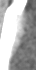


[case_idx=33] ID_5fe1b289_ID_0f30dec3b3_s019_inst1  GT=EDH  VLM=SDH


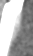


[case_idx=35] ID_75e616a8_ID_8ce0debeb1_s017_inst1  GT=SDH  VLM=IPH


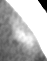


[case_idx=35] ID_75e616a8_ID_8ce0debeb1_s018_inst2  GT=SDH  VLM=NONE


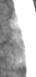


[case_idx=35] ID_75e616a8_ID_8ce0debeb1_s019_inst2  GT=SDH  VLM=IPH


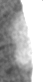


[case_idx=35] ID_75e616a8_ID_8ce0debeb1_s021_inst1  GT=SDH  VLM=EDH


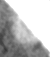


[case_idx=35] ID_75e616a8_ID_8ce0debeb1_s023_inst1  GT=SDH  VLM=NONE


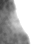


[case_idx=36] ID_7742a473_ID_9f006ce4ef_s017_inst1  GT=IVH  VLM=IPH


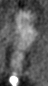


[case_idx=36] ID_7742a473_ID_9f006ce4ef_s018_inst1  GT=IVH  VLM=SAH


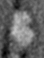


[case_idx=37] ID_7eeb6638_ID_02d57cd50b_s006_inst1  GT=IPH  VLM=NONE


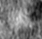


[case_idx=37] ID_7eeb6638_ID_02d57cd50b_s011_inst1  GT=IPH  VLM=NONE


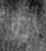


[case_idx=38] ID_8bb2daac_ID_f1994421cc_s011_inst1  GT=IVH  VLM=NONE


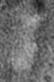


[case_idx=38] ID_8bb2daac_ID_f1994421cc_s012_inst1  GT=IVH  VLM=IPH


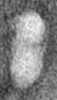


[case_idx=38] ID_8bb2daac_ID_f1994421cc_s012_inst2  GT=IVH  VLM=NONE



[case_idx=38] ID_8bb2daac_ID_f1994421cc_s012_inst3  GT=IVH  VLM=IPH



[case_idx=38] ID_8bb2daac_ID_f1994421cc_s013_inst1  GT=IVH  VLM=IPH


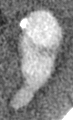


[case_idx=38] ID_8bb2daac_ID_f1994421cc_s013_inst2  GT=IVH  VLM=NONE



[case_idx=38] ID_8bb2daac_ID_f1994421cc_s014_inst1  GT=IVH  VLM=IPH


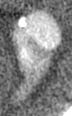


[case_idx=38] ID_8bb2daac_ID_f1994421cc_s014_inst2  GT=IVH  VLM=NONE



[case_idx=38] ID_8bb2daac_ID_f1994421cc_s015_inst1  GT=IVH  VLM=IPH


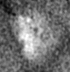


[case_idx=38] ID_8bb2daac_ID_f1994421cc_s016_inst3  GT=IVH  VLM=NONE


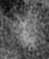


[case_idx=39] ID_90ae3af3_ID_8d77fcb5d2_s007_inst1  GT=SAH  VLM=NONE



[case_idx=39] ID_90ae3af3_ID_8d77fcb5d2_s007_inst2  GT=SAH  VLM=NONE



[case_idx=39] ID_90ae3af3_ID_8d77fcb5d2_s009_inst1  GT=IPH  VLM=SAH


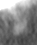


[case_idx=39] ID_90ae3af3_ID_8d77fcb5d2_s009_inst2  GT=IPH  VLM=SDH


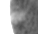


[case_idx=39] ID_90ae3af3_ID_8d77fcb5d2_s010_inst2  GT=SAH  VLM=NONE



[case_idx=39] ID_90ae3af3_ID_8d77fcb5d2_s011_inst2  GT=SAH  VLM=NONE



[case_idx=39] ID_90ae3af3_ID_8d77fcb5d2_s011_inst3  GT=SDH  VLM=NONE


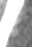


[case_idx=39] ID_90ae3af3_ID_8d77fcb5d2_s011_inst4  GT=SDH  VLM=NONE



[case_idx=39] ID_90ae3af3_ID_8d77fcb5d2_s011_inst5  GT=SDH  VLM=NONE



[case_idx=39] ID_90ae3af3_ID_8d77fcb5d2_s012_inst3  GT=SDH  VLM=NONE



[case_idx=39] ID_90ae3af3_ID_8d77fcb5d2_s014_inst1  GT=SDH  VLM=NONE



[case_idx=39] ID_90ae3af3_ID_8d77fcb5d2_s016_inst1  GT=SAH  VLM=NONE


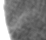


[case_idx=39] ID_90ae3af3_ID_8d77fcb5d2_s019_inst1  GT=SAH  VLM=NONE



[case_idx=39] ID_90ae3af3_ID_8d77fcb5d2_s020_inst1  GT=SAH  VLM=NONE



[case_idx=40] ID_93e3cc83_ID_c0e899cc25_s007_inst2  GT=SAH  VLM=NONE



[case_idx=40] ID_93e3cc83_ID_c0e899cc25_s008_inst1  GT=NONE  VLM=IPH


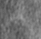


[case_idx=40] ID_93e3cc83_ID_c0e899cc25_s008_inst2  GT=SAH  VLM=IPH



[case_idx=40] ID_93e3cc83_ID_c0e899cc25_s008_inst3  GT=SAH  VLM=NONE


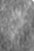


[case_idx=40] ID_93e3cc83_ID_c0e899cc25_s008_inst4  GT=SAH  VLM=IPH



[case_idx=40] ID_93e3cc83_ID_c0e899cc25_s009_inst1  GT=SAH  VLM=NONE


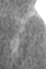


[case_idx=40] ID_93e3cc83_ID_c0e899cc25_s010_inst2  GT=SAH  VLM=NONE


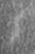


[case_idx=40] ID_93e3cc83_ID_c0e899cc25_s011_inst1  GT=NONE  VLM=IPH


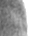


[case_idx=40] ID_93e3cc83_ID_c0e899cc25_s011_inst2  GT=SAH  VLM=IPH



[case_idx=40] ID_93e3cc83_ID_c0e899cc25_s011_inst3  GT=SAH  VLM=IPH



[case_idx=40] ID_93e3cc83_ID_c0e899cc25_s011_inst4  GT=SAH  VLM=IPH



[case_idx=40] ID_93e3cc83_ID_c0e899cc25_s011_inst5  GT=SAH  VLM=NONE



[case_idx=40] ID_93e3cc83_ID_c0e899cc25_s011_inst6  GT=SAH  VLM=NONE



[case_idx=40] ID_93e3cc83_ID_c0e899cc25_s012_inst1  GT=NONE  VLM=IPH



[case_idx=40] ID_93e3cc83_ID_c0e899cc25_s012_inst2  GT=SAH  VLM=IPH



[case_idx=40] ID_93e3cc83_ID_c0e899cc25_s012_inst3  GT=SAH  VLM=IPH



[case_idx=40] ID_93e3cc83_ID_c0e899cc25_s012_inst4  GT=SAH  VLM=NONE


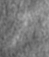


[case_idx=40] ID_93e3cc83_ID_c0e899cc25_s013_inst1  GT=NONE  VLM=IPH



[case_idx=40] ID_93e3cc83_ID_c0e899cc25_s013_inst2  GT=SAH  VLM=IPH



[case_idx=40] ID_93e3cc83_ID_c0e899cc25_s013_inst3  GT=SAH  VLM=NONE


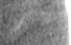


[case_idx=40] ID_93e3cc83_ID_c0e899cc25_s014_inst1  GT=SAH  VLM=NONE



[case_idx=40] ID_93e3cc83_ID_c0e899cc25_s014_inst2  GT=SAH  VLM=IPH


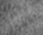


[case_idx=41] ID_96bb7e1d_ID_4b827bde69_s011_inst1  GT=NONE  VLM=SAH


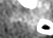


[case_idx=41] ID_96bb7e1d_ID_4b827bde69_s012_inst4  GT=NONE  VLM=SAH



[case_idx=41] ID_96bb7e1d_ID_4b827bde69_s012_inst6  GT=SAH  VLM=NONE



[case_idx=41] ID_96bb7e1d_ID_4b827bde69_s014_inst1  GT=SAH  VLM=IPH


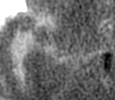


[case_idx=41] ID_96bb7e1d_ID_4b827bde69_s014_inst2  GT=NONE  VLM=SAH



[case_idx=41] ID_96bb7e1d_ID_4b827bde69_s014_inst5  GT=NONE  VLM=SAH



[case_idx=41] ID_96bb7e1d_ID_4b827bde69_s014_inst8  GT=NONE  VLM=SAH



[case_idx=41] ID_96bb7e1d_ID_4b827bde69_s014_inst10  GT=SDH  VLM=SAH


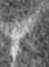


[case_idx=41] ID_96bb7e1d_ID_4b827bde69_s014_inst11  GT=SDH  VLM=SAH



[case_idx=41] ID_96bb7e1d_ID_4b827bde69_s015_inst1  GT=NONE  VLM=SAH


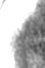


[case_idx=41] ID_96bb7e1d_ID_4b827bde69_s015_inst3  GT=SAH  VLM=SDH


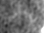


[case_idx=41] ID_96bb7e1d_ID_4b827bde69_s015_inst6  GT=NONE  VLM=SAH


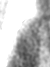


[case_idx=41] ID_96bb7e1d_ID_4b827bde69_s015_inst7  GT=NONE  VLM=SAH



[case_idx=41] ID_96bb7e1d_ID_4b827bde69_s015_inst10  GT=NONE  VLM=SAH



[case_idx=41] ID_96bb7e1d_ID_4b827bde69_s015_inst11  GT=SAH  VLM=NONE


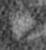


[case_idx=41] ID_96bb7e1d_ID_4b827bde69_s015_inst12  GT=SAH  VLM=NONE



[case_idx=41] ID_96bb7e1d_ID_4b827bde69_s015_inst13  GT=SDH  VLM=SAH


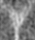


[case_idx=41] ID_96bb7e1d_ID_4b827bde69_s016_inst1  GT=NONE  VLM=SAH


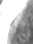


[case_idx=41] ID_96bb7e1d_ID_4b827bde69_s016_inst2  GT=NONE  VLM=SAH



[case_idx=41] ID_96bb7e1d_ID_4b827bde69_s016_inst5  GT=SAH  VLM=SDH


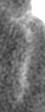


[case_idx=41] ID_96bb7e1d_ID_4b827bde69_s016_inst6  GT=NONE  VLM=SAH


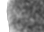


[case_idx=41] ID_96bb7e1d_ID_4b827bde69_s016_inst9  GT=IVH  VLM=IPH


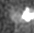


[case_idx=41] ID_96bb7e1d_ID_4b827bde69_s016_inst10  GT=IVH  VLM=IPH


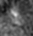


[case_idx=41] ID_96bb7e1d_ID_4b827bde69_s016_inst11  GT=SDH  VLM=SAH



[case_idx=41] ID_96bb7e1d_ID_4b827bde69_s016_inst12  GT=SAH  VLM=NONE


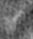


[case_idx=41] ID_96bb7e1d_ID_4b827bde69_s017_inst2  GT=NONE  VLM=SAH



[case_idx=41] ID_96bb7e1d_ID_4b827bde69_s017_inst7  GT=SAH  VLM=NONE



[case_idx=41] ID_96bb7e1d_ID_4b827bde69_s017_inst8  GT=SAH  VLM=NONE


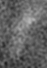


[case_idx=41] ID_96bb7e1d_ID_4b827bde69_s017_inst9  GT=SAH  VLM=IPH


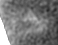


[case_idx=41] ID_96bb7e1d_ID_4b827bde69_s017_inst10  GT=IVH  VLM=IPH


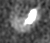


[case_idx=41] ID_96bb7e1d_ID_4b827bde69_s017_inst11  GT=SDH  VLM=IVH


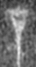


[case_idx=41] ID_96bb7e1d_ID_4b827bde69_s018_inst2  GT=SAH  VLM=NONE



[case_idx=41] ID_96bb7e1d_ID_4b827bde69_s018_inst3  GT=NONE  VLM=IPH



[case_idx=41] ID_96bb7e1d_ID_4b827bde69_s018_inst4  GT=SAH  VLM=IPH



[case_idx=41] ID_96bb7e1d_ID_4b827bde69_s018_inst6  GT=SAH  VLM=IPH


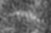


[case_idx=41] ID_96bb7e1d_ID_4b827bde69_s018_inst7  GT=SAH  VLM=NONE


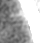


[case_idx=41] ID_96bb7e1d_ID_4b827bde69_s018_inst8  GT=SAH  VLM=IPH


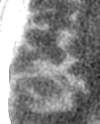


[case_idx=41] ID_96bb7e1d_ID_4b827bde69_s018_inst9  GT=SAH  VLM=NONE



[case_idx=41] ID_96bb7e1d_ID_4b827bde69_s018_inst10  GT=SAH  VLM=NONE


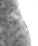


[case_idx=41] ID_96bb7e1d_ID_4b827bde69_s018_inst11  GT=SAH  VLM=NONE


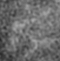


[case_idx=41] ID_96bb7e1d_ID_4b827bde69_s018_inst12  GT=SAH  VLM=NONE


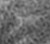


[case_idx=41] ID_96bb7e1d_ID_4b827bde69_s018_inst13  GT=SAH  VLM=NONE



[case_idx=41] ID_96bb7e1d_ID_4b827bde69_s018_inst14  GT=SAH  VLM=NONE



[case_idx=41] ID_96bb7e1d_ID_4b827bde69_s018_inst15  GT=IVH  VLM=IPH


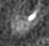


[case_idx=41] ID_96bb7e1d_ID_4b827bde69_s018_inst16  GT=IVH  VLM=IPH



[case_idx=41] ID_96bb7e1d_ID_4b827bde69_s018_inst17  GT=SAH  VLM=IPH



[case_idx=41] ID_96bb7e1d_ID_4b827bde69_s018_inst18  GT=SDH  VLM=IPH



[case_idx=41] ID_96bb7e1d_ID_4b827bde69_s018_inst19  GT=SAH  VLM=IPH


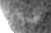


[case_idx=41] ID_96bb7e1d_ID_4b827bde69_s019_inst1  GT=SDH  VLM=NONE


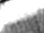


[case_idx=41] ID_96bb7e1d_ID_4b827bde69_s019_inst2  GT=SAH  VLM=NONE



[case_idx=41] ID_96bb7e1d_ID_4b827bde69_s019_inst3  GT=SAH  VLM=NONE



[case_idx=41] ID_96bb7e1d_ID_4b827bde69_s019_inst4  GT=SAH  VLM=NONE


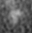


[case_idx=41] ID_96bb7e1d_ID_4b827bde69_s019_inst7  GT=SAH  VLM=NONE


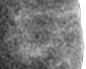


[case_idx=41] ID_96bb7e1d_ID_4b827bde69_s019_inst8  GT=IVH  VLM=NONE


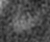


[case_idx=41] ID_96bb7e1d_ID_4b827bde69_s020_inst1  GT=SAH  VLM=NONE



[case_idx=41] ID_96bb7e1d_ID_4b827bde69_s020_inst2  GT=SAH  VLM=IPH


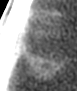


[case_idx=41] ID_96bb7e1d_ID_4b827bde69_s020_inst3  GT=SAH  VLM=NONE



[case_idx=41] ID_96bb7e1d_ID_4b827bde69_s020_inst4  GT=SAH  VLM=IPH


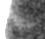


[case_idx=41] ID_96bb7e1d_ID_4b827bde69_s020_inst5  GT=SAH  VLM=NONE


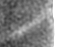


[case_idx=41] ID_96bb7e1d_ID_4b827bde69_s020_inst6  GT=SAH  VLM=IPH


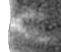


[case_idx=41] ID_96bb7e1d_ID_4b827bde69_s020_inst7  GT=SAH  VLM=IPH



[case_idx=41] ID_96bb7e1d_ID_4b827bde69_s021_inst1  GT=SAH  VLM=NONE



[case_idx=41] ID_96bb7e1d_ID_4b827bde69_s021_inst2  GT=SAH  VLM=NONE



[case_idx=41] ID_96bb7e1d_ID_4b827bde69_s021_inst3  GT=SAH  VLM=IPH



[case_idx=41] ID_96bb7e1d_ID_4b827bde69_s021_inst5  GT=SAH  VLM=NONE



[case_idx=41] ID_96bb7e1d_ID_4b827bde69_s021_inst7  GT=SAH  VLM=NONE



[case_idx=41] ID_96bb7e1d_ID_4b827bde69_s021_inst8  GT=SAH  VLM=NONE


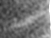


[case_idx=41] ID_96bb7e1d_ID_4b827bde69_s021_inst10  GT=SAH  VLM=NONE



[case_idx=41] ID_96bb7e1d_ID_4b827bde69_s022_inst1  GT=SAH  VLM=NONE



[case_idx=41] ID_96bb7e1d_ID_4b827bde69_s022_inst2  GT=SAH  VLM=NONE



[case_idx=41] ID_96bb7e1d_ID_4b827bde69_s022_inst3  GT=SAH  VLM=NONE


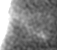


[case_idx=41] ID_96bb7e1d_ID_4b827bde69_s022_inst5  GT=SAH  VLM=IPH



[case_idx=41] ID_96bb7e1d_ID_4b827bde69_s022_inst6  GT=SAH  VLM=NONE



[case_idx=41] ID_96bb7e1d_ID_4b827bde69_s023_inst1  GT=SAH  VLM=NONE


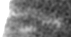


[case_idx=41] ID_96bb7e1d_ID_4b827bde69_s023_inst2  GT=SAH  VLM=NONE



[case_idx=41] ID_96bb7e1d_ID_4b827bde69_s024_inst1  GT=SAH  VLM=NONE


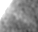


[case_idx=41] ID_96bb7e1d_ID_4b827bde69_s024_inst2  GT=SAH  VLM=NONE



[case_idx=41] ID_96bb7e1d_ID_4b827bde69_s024_inst3  GT=SAH  VLM=NONE



[case_idx=41] ID_96bb7e1d_ID_4b827bde69_s025_inst1  GT=SAH  VLM=NONE



[case_idx=41] ID_96bb7e1d_ID_4b827bde69_s026_inst1  GT=SAH  VLM=NONE



[case_idx=42] ID_fd77bee7_ID_60083050a8_s007_inst1  GT=NONE  VLM=IPH


,id,case_id,slice_idx,instance_number,bbox,area_px,images,vlm_is_lesion,vlm_lesion_type,gt_is_lesion,gt_class_name,gt_label,vlm_label,case_idx
0,ID_0219ef88_ID_e5c1a31210_s013_inst1,ID_0219ef88_ID_e5c1a31210,13,1,"[184, 369, 204, 377]",50,{'overlay': '/home/jovyan/aicon-gamma-datavol-...,False,NONE,True,SDH,SDH,NONE,0
1,ID_066b1fc2_ID_f937d7bff0_s011_inst1,ID_066b1fc2_ID_f937d7bff0,11,1,"[367, 189, 375, 197]",49,{'overlay': '/home/jovyan/aicon-gamma-datavol-...,True,IPH,True,IVH,IVH,IPH,1
2,ID_066b1fc2_ID_f937d7bff0_s012_inst1,ID_066b1fc2_ID_f937d7bff0,12,1,"[366, 190, 371, 195]",20,{'overlay': '/home/jovyan/aicon-gamma-datavol-...,False,NONE,True,IVH,IVH,NONE,1
3,ID_066b1fc2_ID_f937d7bff0_s013_inst1,ID_066b1fc2_ID_f937d7bff0,13,1,"[372, 195, 380, 204]",48,{'overlay': '/home/jovyan/aicon-gamma-datavol-...,True,IPH,True,IVH,IVH,IPH,1
4,ID_066b1fc2_ID_f937d7bff0_s013_inst2,ID_066b1fc2_ID_f937d7bff0,13,2,"[382, 299, 387, 306]",29,{'overlay': '/home/jovyan/aicon-gamma-datavol-...,False,NONE,True,IVH,IVH,NONE,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
953,ID_96bb7e1d_ID_4b827bde69_s024_inst2,ID_96bb7e1d_ID_4b827bde69,24,2,"[206, 130, 213, 155]",108,{'overlay': '/home/jovyan/aicon-gamma-datavol-...,False,NONE,True,SAH,SAH,NONE,41
954,ID_96bb7e1d_ID_4b827bde69_s024_inst3,ID_96bb7e1d_ID_4b827bde69,24,3,"[243, 157, 246, 161]",9,{'overlay': '/home/jovyan/aicon-gamma-datavol-...,False,NONE,True,SAH,SAH,NONE,41
955,ID_96bb7e1d_ID_4b827bde69_s025_inst1,ID_96bb7e1d_ID_4b827bde69,25,1,"[284, 288, 288, 294]",20,{'overlay': '/home/jovyan/aicon-gamma-datavol-...,False,NONE,True,SAH,SAH,NONE,41
956,ID_96bb7e1d_ID_4b827bde69_s026_inst1,ID_96bb7e1d_ID_4b827bde69,26,1,"[216, 236, 218, 238]",4,{'overlay': '/home/jovyan/aicon-gamma-datavol-...,False,NONE,True,SAH,SAH,NONE,41


In [77]:
def show_vlm_errors(pred_records, max_display=None):
    df = pd.DataFrame(with_ground_truth(pred_records))

    gt_label = np.where(df["gt_is_lesion"], df["gt_class_name"], "NONE")
    vlm_label = np.where(df["vlm_is_lesion"], df["vlm_lesion_type"], "NONE")
    is_wrong = gt_label != vlm_label
    errors = df[is_wrong].copy()
    errors["gt_label"] = gt_label[is_wrong]
    errors["vlm_label"] = vlm_label[is_wrong]
    errors["case_idx"] = errors["case_id"].map(lambda cid: dataset_case_ids.index(cid))

    print(f"오답 {len(errors)}개 / 전체 {len(df)}개 (정확도 {1 - len(errors) / len(df):.4f})")

    shown = errors if max_display is None else errors.head(max_display)
    for _, r in shown.iterrows():
        print(f"\n[case_idx={r['case_idx']}] {r['id']}  GT={r['gt_label']}  VLM={r['vlm_label']}")
        display(Image.open(r["images"]["cropped"]))

    return errors

show_vlm_errors(results_to_eval)

In [78]:
errors_df = show_vlm_errors(results_to_eval, max_display=0)  # max_display=0 → 이미지 출력 없이 df만

out_csv = EXP_OUT_DIR / "output" / "vlm_errors.csv"
save_df = errors_df.copy()
save_df["overlay_path"] = save_df["images"].map(lambda d: d["overlay"])
save_df["crop_path"] = save_df["images"].map(lambda d: d["cropped"])
save_df = save_df.drop(columns=["images"])
save_df.to_csv(out_csv, index=False)
print(f"저장: {out_csv} ({len(save_df)}개)")

오답 585개 / 전체 958개 (정확도 0.3894)
저장: /home/jovyan/aicon-gamma-datavol-1/hjgoh/ich-vlm/experiments/260818_vlm-classify-mbhseg-dataset/output/vlm_errors.csv (585개)


In [79]:
def correct_case_volume(case_id, records_for_case):
    """2cls라 클래스 재라벨링 없이, false positive만 제거(0)한다."""
    pred = load_lps_array(pred_root / f"{case_id}.nii.gz").astype(np.uint8)
    corrected = pred.copy()

    by_slice = {}
    for r in records_for_case:
        by_slice.setdefault(r["slice_idx"], []).append(r)

    for z, recs in by_slice.items():
        labeled = sklabel(pred[z] > 0)
        bbox_to_id = {tuple(region.bbox): region.label for region in regionprops(labeled)}
        for r in recs:
            inst_id = bbox_to_id.get(tuple(r["bbox"]))
            if inst_id is None:
                print(f"[경고] bbox 매칭 실패: {r['id']}")
                continue
            if not r["vlm_is_lesion"]:
                corrected[z][labeled == inst_id] = 0

    return corrected


def save_corrected(case_id, corrected):
    ref_img = sitk.DICOMOrient(sitk.ReadImage(str(pred_root / f"{case_id}.nii.gz")), "LPS")
    out_img = sitk.GetImageFromArray(corrected.astype(np.uint8))
    out_img.CopyInformation(ref_img)
    out_dir = EXP_OUT_DIR / "output" / "corrected_masks"
    out_dir.mkdir(parents=True, exist_ok=True)
    out_path = out_dir / f"non_thinking__{case_id}.nii.gz"
    sitk.WriteImage(out_img, str(out_path))
    return out_path


by_case = {}
for r in results_to_eval:
    by_case.setdefault(r["case_id"], []).append(r)

for case_id, recs in by_case.items():
    corrected = correct_case_volume(case_id, recs)
    save_corrected(case_id, corrected)
print(f"non_thinking: {len(by_case)}개 케이스 보정 마스크 저장 완료")

non_thinking: 43개 케이스 보정 마스크 저장 완료


In [80]:
def evaluate_dice(pred_paths, gt_dir, classes):
    """case x class 단위 Dice. 둘 다 foreground 없으면 NaN."""
    rows = []
    for case_id, pred_path in pred_paths.items():
        gt = load_lps_array(gt_dir / f"{case_id}.nii.gz").astype(np.uint8)
        pred = load_lps_array(pred_path).astype(np.uint8)
        for c in classes:
            p, g = pred == c, gt == c
            if p.sum() == 0 and g.sum() == 0:
                dice = np.nan
            else:
                inter = np.logical_and(p, g).sum()
                dice = 2 * inter / (p.sum() + g.sum())
            rows.append({"case_id": case_id, "class": c, "Dice": dice})
    return pd.DataFrame(rows)


case_ids_evaluated = sorted({r["case_id"] for r in results_to_eval})
eval_baseline_paths = {cid: pred_root / f"{cid}.nii.gz" for cid in case_ids_evaluated}
eval_baseline_df = evaluate_dice(eval_baseline_paths, labels_dir, FG_CLASSES)
print(f"원본(보정 전) 평균 Dice: {eval_baseline_df['Dice'].mean():.4f}  (n={len(eval_baseline_df)})")

corrected_paths = {
    p.stem.replace(".nii", "")[len("non_thinking__"):]: p
    for p in (EXP_OUT_DIR / "output" / "corrected_masks").glob("non_thinking__*.nii.gz")
}
corrected_df = evaluate_dice(corrected_paths, labels_dir, FG_CLASSES)
print(f"VLM 보정 후 평균 Dice: {corrected_df['Dice'].mean():.4f}  (n={len(corrected_df)})")

summary_df = pd.DataFrame([
    {"config": "baseline (보정 전)", "mean_dice": eval_baseline_df["Dice"].mean(), "n_cases": len(eval_baseline_df)},
    {"config": "non_thinking (보정 후)", "mean_dice": corrected_df["Dice"].mean(), "n_cases": len(corrected_df)},
])
display(summary_df)
summary_df.to_csv(EXP_OUT_DIR / "output" / "dice_comparison.csv", index=False)
print(f"\n저장: {EXP_OUT_DIR / 'output' / 'dice_comparison.csv'}")

원본(보정 전) 평균 Dice: 0.6331  (n=43)
VLM 보정 후 평균 Dice: 0.5633  (n=43)


,config,mean_dice,n_cases
0,baseline (보정 전),0.633132,43
1,non_thinking (보정 후),0.563263,43



저장: /home/jovyan/aicon-gamma-datavol-1/hjgoh/ich-vlm/experiments/260818_vlm-classify-mbhseg-dataset/output/dice_comparison.csv


In [81]:
from skimage.measure import label as sklabel, regionprops

GT_5CLS_DIR = Path("/home/jovyan/aicon-gamma-datavol-1/hjgoh/ich-vlm/nnUNet/test_data/Test1_MBHSeg25/labelsTs")
name_to_class = {v: k for k, v in class_names.items()}


def show_case(case_idx, slice_idx=None):
    """case_idx: dataset_case_ids에서의 순번 (errors_df/vlm_eval_df의 case_idx와 동일 기준).
    slice_idx를 주면 그 슬라이스, 안 주면 5cls GT 전경이 가장 많은 슬라이스를 자동 선택.
    3번째 패널은 2cls pred를 VLM 판정으로 재라벨링한 5cls 마스크 + 정답/오답 bbox."""
    case_id = dataset_case_ids[case_idx]
    img = load_lps_array(images_dir / f"{case_id}_0000.nii.gz")
    gt_5cls = load_lps_array(GT_5CLS_DIR / f"{case_id}.nii.gz").astype(np.uint8)
    pred = load_lps_array(pred_root / f"{case_id}.nii.gz").astype(np.uint8)

    if slice_idx is None:
        fg_per_slice = (gt_5cls > 0).sum(axis=(1, 2))
        slice_idx = int(fg_per_slice.argmax())

    windowed = apply_window(img[slice_idx])
    gt_slice = gt_5cls[slice_idx]
    pred_slice = pred[slice_idx]

    slice_recs = [r for r in results_to_eval if r["case_id"] == case_id and r["slice_idx"] == slice_idx]
    joined = with_ground_truth(slice_recs)

    # pred 2cls -> VLM classifier 판정으로 재라벨링한 5cls 마스크
    labeled = sklabel(pred_slice > 0)
    bbox_to_id = {tuple(region.bbox): region.label for region in regionprops(labeled)}
    vlm_mask = np.zeros_like(pred_slice)
    for r in joined:
        inst_id = bbox_to_id.get(tuple(r["bbox"]))
        if inst_id is None or not r["vlm_is_lesion"]:
            continue
        vlm_mask[labeled == inst_id] = name_to_class.get(r["vlm_lesion_type"], 0)

    gt_overlay = np.ma.masked_where(gt_slice == 0, gt_slice)
    vlm_overlay = np.ma.masked_where(vlm_mask == 0, vlm_mask)

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    axes[0].imshow(windowed, cmap="gray", vmin=0, vmax=1)
    axes[0].set_title(f"{case_id} (z={slice_idx}/{img.shape[0]-1})")
    axes[0].axis("off")

    axes[1].imshow(windowed, cmap="gray", vmin=0, vmax=1)
    axes[1].imshow(gt_overlay, cmap=cmap_5cls, vmin=0, vmax=5, alpha=0.6)
    axes[1].set_title("GT mask (5cls)")
    axes[1].axis("off")

    axes[2].imshow(windowed, cmap="gray", vmin=0, vmax=1)
    axes[2].imshow(vlm_overlay, cmap=cmap_5cls, vmin=0, vmax=5, alpha=0.6)
    axes[2].set_title("Pred 2cls → VLM classifier (5cls)")
    axes[2].axis("off")

    for r in joined:
        y0, x0, y1, x1 = r["bbox"]
        gt_lbl = r["gt_class_name"] if r["gt_is_lesion"] else "NONE"
        vlm_lbl = r["vlm_lesion_type"] if r["vlm_is_lesion"] else "NONE"
        correct = gt_lbl == vlm_lbl
        color = "lime" if correct else "red"
        rect = plt.Rectangle((x0, y0), x1 - x0, y1 - y0, fill=False, edgecolor=color, linewidth=1.5)
        axes[2].add_patch(rect)
        

    plt.tight_layout()
    plt.show()

    print(f"case: {case_id} | z: {slice_idx}")
    for r in joined:
        gt_lbl = r["gt_class_name"] if r["gt_is_lesion"] else "NONE"
        vlm_lbl = r["vlm_lesion_type"] if r["vlm_is_lesion"] else "NONE"
        print(f"  inst {r['instance_number']}: GT={gt_lbl} | VLM={vlm_lbl}")

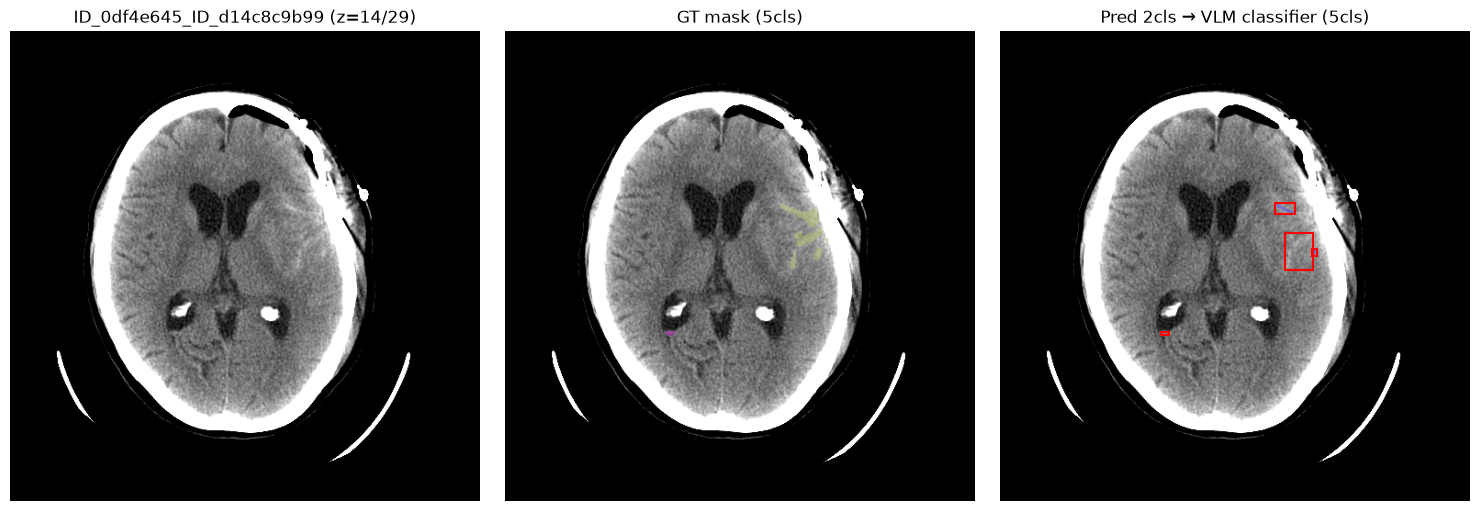

case: ID_0df4e645_ID_d14c8c9b99 | z: 14
  inst 1: GT=SAH | VLM=IPH
  inst 2: GT=SAH | VLM=NONE
  inst 3: GT=SAH | VLM=IPH
  inst 4: GT=IVH | VLM=NONE


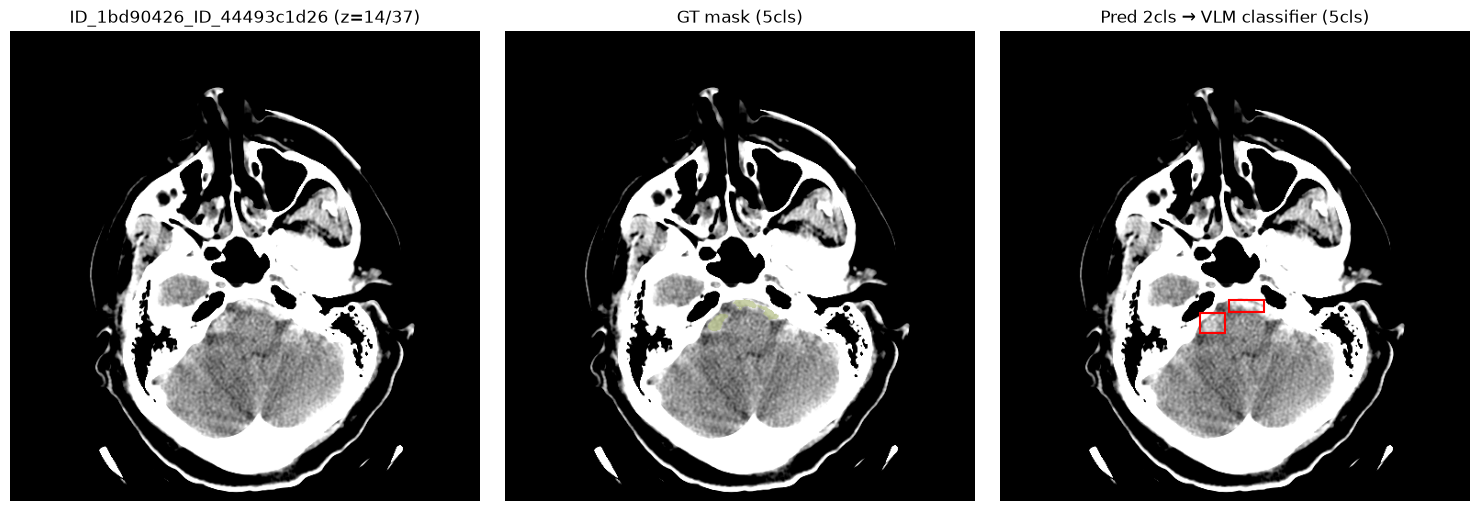

case: ID_1bd90426_ID_44493c1d26 | z: 14
  inst 1: GT=SAH | VLM=NONE
  inst 2: GT=SAH | VLM=NONE


In [82]:
show_case(case_idx=8, slice_idx=14)   # ID_0d0f361b_ID_17542973dc, SAH->IPH
show_case(case_idx=17, slice_idx=14)  # ID_0f320c56_ID_27f2bce652, SDH->EDH

In [ ]:
def find_missed_gt_instances(case_ids, gt_dir, pred_dir, min_pixels=5):
    """GT ICH connected component 중, 
    같은 자리에 pred(Reader#1) 픽셀이 전혀 없는(완전히 놓친)것만 찾는다. 
    지금까지의 detect_acc/confusion은 전부 'pred가 만든 connected component'에서
    출발해서, 이런 완전 누락(진짜 false negative)은 애초에 인스턴스로 존재한 적이 없어 반영되지 않았음
    """
    missed = []
    for case_id in case_ids:
        gt = load_lps_array(gt_dir / f"{case_id}.nii.gz").astype(np.uint8)
        pred = load_lps_array(pred_dir / f"{case_id}.nii.gz").astype(np.uint8)
        for z in range(gt.shape[0]):
            gt_slice = gt[z]
            if not np.any(gt_slice > 0):
                continue
            pred_slice = pred[z]
            labeled = sklabel(gt_slice > 0)
            for region in regionprops(labeled):
                inst_mask = labeled == region.label
                if inst_mask.sum() < min_pixels:
                    continue
                if not np.any(pred_slice[inst_mask] > 0):
                    missed.append({"case_id": case_id, "slice_idx": z, "pixel_count": int(inst_mask.sum())})
    return missed


missed_instances = find_missed_gt_instances(case_ids_evaluated, labels_dir, pred_root)

n_tp = int(vlm_eval_df["gt_is_lesion"].sum())        # GT=ich, pred=ich (Reader#1이 후보로 만들었고 실제로도 병변)
n_fn = len(missed_instances)                          # GT=ich, pred=background (완전히 놓침 — 애초에 후보 인스턴스가 없었음)
n_fp = int((~vlm_eval_df["gt_is_lesion"]).sum())      # GT=background, pred=ich (과검출)

# GT=background, pred=background은 전체 배경 픽셀 전체라 "인스턴스" 개념이 없어 정의 불가 → NaN
full_confusion = pd.DataFrame(
    [[n_tp, n_fn], [n_fp, np.nan]],
    index=pd.Index(["ich", "background"], name="GT"),
    columns=pd.Index(["ich", "background"], name="pred"),
)

print("=== pred vs GT confusion matrix (배경/완전 누락 포함) ===")
display(full_confusion)

print(f"\n놓침까지 포함한 진짜 recall: {n_tp / (n_tp + n_fn):.4f}")
print(f"precision: {n_tp / (n_tp + n_fp):.4f}")
print(f"(참고: 지금까지 쓰던 detect_acc 등은 pred가 만든 {len(vlm_eval_df)}개 후보 인스턴스 안에서만 계산된 것이라, 이 완전 누락 {n_fn}개는 반영돼 있지 않았음)")

=== pred vs GT confusion matrix (배경/완전 누락 포함) ===


pred,ich,background
GT,,
ich,735,382.0
background,223,NaN



놓침까지 포함한 진짜 recall: 0.6580
precision: 0.7672
(참고: 지금까지 쓰던 detect_acc 등은 pred가 만든 958개 후보 인스턴스 안에서만 계산된 것이라, 이 완전 누락 382개는 반영돼 있지 않았음)
